In [1]:
import pypsa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import gurobipy as gp
from gurobipy import GRB
import os
import pypsatopo
import warnings
warnings.filterwarnings("ignore")
import cartopy.crs as ccrs
from shapely.errors import ShapelyDeprecationWarning
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning)   

### Default Technology Cost DataBase:

In [2]:
year = 2030
url = f"https://raw.githubusercontent.com/PyPSA/technology-data/master/outputs/costs_{year}.csv"
costs = pd.read_csv(url, index_col=[0, 1])

In [3]:
costs.loc[costs.unit.str.contains("/kW"), "value"] *= 1e3
costs.unit = costs.unit.str.replace("/kW", "/MW")

defaults = {
    "FOM": 0,
    "VOM": 0,
    "efficiency": 1,
    "fuel": 0,
    "investment": 0,
    "lifetime": 25,
    "CO2 intensity": 0,
    "discount rate": 0.07,
}
costs = costs.value.unstack().fillna(defaults)

costs.at["OCGT", "fuel"] = costs.at["gas", "fuel"]
costs.at["OCGT", "CO2 intensity"] = costs.at["gas", "CO2 intensity"]

- all capital cost inputs are annualized

In [4]:
def annuity(r, n):
    return r / (1.0 - 1.0 / (1.0 + r) ** n)

costs["marginal_cost"] = costs["VOM"] + costs["fuel"] / costs["efficiency"];

annuity = costs.apply(lambda x: annuity(x["discount rate"], x["lifetime"]), axis=1);

costs["capital_cost"] = (annuity + costs["FOM"] / 100) * costs["investment"]

### Data Inputs

In [5]:
# Get the directory of the current script
current_dir = os.getcwd()

# Build file paths relative to the script location
pv_file = os.path.join(current_dir, "pv_optimal.csv")
wind_file = os.path.join(current_dir, "onshore_wind_1979-2017.csv")
dk1_file = os.path.join(current_dir, "2017_DK1_SpotSprice_Load.xlsx")
# dk1_file = os.path.join(current_dir, "DK1_2017.csv")  # optional alternative

# Read the files
solar_pv_data = pd.read_csv(pv_file, sep=";")
onshore_wind_data = pd.read_csv(wind_file, sep=";")
DK1_data_2017 = pd.read_excel(dk1_file)

In [6]:
gas_file = os.path.join(current_dir, 'GasDailyBalancingPrice.xlsx')

<Axes: >

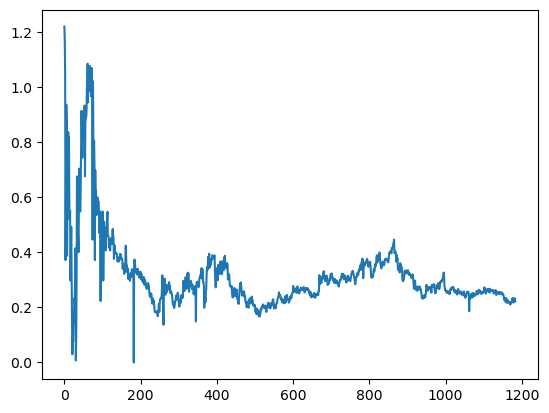

In [7]:
gas_price_data = pd.read_excel(gas_file);
gas_price_data["MarginalPurchasePriceDKK_kWh"].plot() # DKK/KWh


In [8]:
# 1. Convert the 'GasDay' column to datetime and remove timezone offset
gas_price_data["GasDay"] = pd.to_datetime(gas_price_data["GasDay"]).dt.tz_localize(None)
# 2. Set the 'GasDay' column as the index
gas_price_data.index = pd.DatetimeIndex(gas_price_data["GasDay"])
# 3. Resample to hourly to match solar_pv_data (forward fill daily prices)
gas_price_hourly = gas_price_data.resample('h').ffill()

In [9]:
EUR_DKK_exchnagerate =(gas_price_hourly["ExchangeRateEUR_DKK"]/100)

<Axes: xlabel='GasDay'>

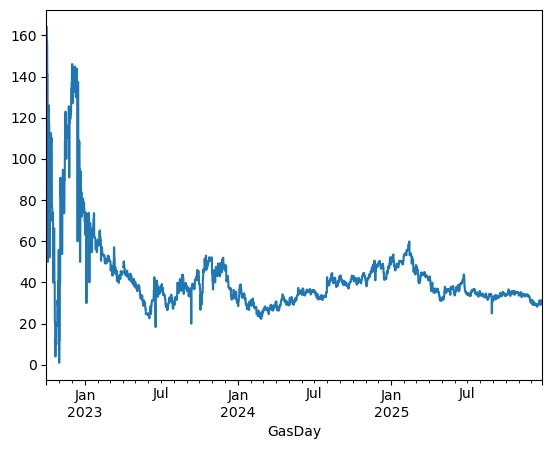

In [10]:
((gas_price_hourly["MarginalPurchasePriceDKK_kWh"]/EUR_DKK_exchnagerate)*1000).plot() # EUR/MWh

In [11]:
gas_price_hourly["MarginalPurchasePriceEUR_MWh"] = ((gas_price_hourly["MarginalPurchasePriceDKK_kWh"]/EUR_DKK_exchnagerate)*1000)
gas_price_hourly["MarginalPurchasePriceEUR_MWh"] 

GasDay
2022-10-01 00:00:00    164.176696
2022-10-01 01:00:00    164.176696
2022-10-01 02:00:00    164.176696
2022-10-01 03:00:00    164.176696
2022-10-01 04:00:00    164.176696
                          ...    
2025-12-26 20:00:00     30.641750
2025-12-26 21:00:00     30.641750
2025-12-26 22:00:00     30.641750
2025-12-26 23:00:00     30.641750
2025-12-27 00:00:00     29.731466
Freq: h, Name: MarginalPurchasePriceEUR_MWh, Length: 28393, dtype: float64

### Gas Prices per 2021

In [12]:
gas_file_pre21 = os.path.join(current_dir, 'GasSystemBalanceUntil20221001.xlsx')
gas_price_data_pre21 = pd.read_excel(gas_file_pre21);

In [13]:
gas_price_data_pre21["GasDay"] = pd.to_datetime(gas_price_data_pre21["GasDay"]).dt.tz_localize(None)
# 2. Set the 'GasDay' column as the index
gas_price_data_pre21.index = pd.DatetimeIndex(gas_price_data_pre21["GasDay"])
# 3. Resample to hourly to match solar_pv_data (forward fill daily prices)
#gas_price_hourly = gas_price_data.resample('h').ffill()

In [14]:
gas_price_data_pre21

,GasDay,Created,BalanceType,Balance,ProductCode,greenZoneMin,greenZoneMax,YellowZoneMin,YellowZoneMax,GasBuyingPriceDKK,GasBuyPriceDescription,GasSellingPriceDKK,GasSellPriceDescription
GasDay,,,,,,,,,,,,,
2021-01-01,2021-01-01,2021-01-01 20:45:27,ESCB,-7159273,Non valid ordinary,-36762360,3237640,-54435000,54435000,NaN,NaN,NaN,NaN
2021-01-01,2021-01-01,2021-02-24 12:41:47,SCB,-22404937,Valid ordinary,-36762360,3237640,-54435000,54435000,0.1332,Marginal adjustment of balance purchase step 1...,0.1346,"Adjustment of balance sale step 1, NG-WD * ADJ..."
2021-01-01,2021-01-01,2021-01-02 00:45:22,ESCB,-12668691,Non valid ordinary,-36762360,3237640,-54435000,54435000,NaN,NaN,NaN,NaN
2021-01-01,2021-01-01,2021-01-02 01:45:22,ESCB,-12950681,Non valid ordinary,-36762360,3237640,-54435000,54435000,NaN,NaN,NaN,NaN
2021-01-01,2021-01-01,2021-01-01 22:45:25,ESCB,-9996461,Non valid ordinary,-36762360,3237640,-54435000,54435000,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-09-30,2022-09-30,2022-10-01 01:45:15,ESCB,3166032,Non valid ordinary,-3758094,12241906,-53575500,53575500,NaN,NaN,NaN,NaN
2022-09-30,2022-09-30,2022-09-30 22:45:23,ESCB,3537232,Non valid ordinary,-3758094,12241906,-53575500,53575500,NaN,NaN,NaN,NaN
2022-09-30,2022-09-30,2022-10-31 07:28:17,SCB,9310742,Valid ordinary,-3758094,12241906,-53575500,53575500,1.2558,"Adjustment of balance purchase step 1, NG-WD *...",1.2684,"Adjustment of balance sale step 1, NG-WD * ADJ..."


In [15]:
gas_price_data_pre21["GasSellingPriceDKK"]

GasDay
2021-01-01       NaN
2021-01-01    0.1346
2021-01-01       NaN
2021-01-01       NaN
2021-01-01       NaN
               ...  
2022-09-30       NaN
2022-09-30       NaN
2022-09-30    1.2684
2022-09-30    1.2684
2022-09-30       NaN
Name: GasSellingPriceDKK, Length: 15866, dtype: float64

<Axes: xlabel='GasDay'>

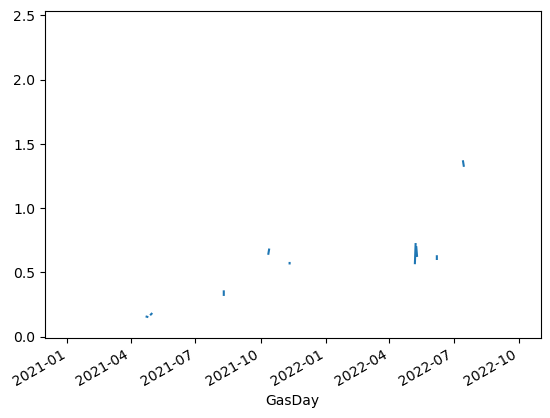

In [16]:
gas_price_data_pre21["GasSellingPriceDKK"].plot() # DKK/kWh

In [17]:
(3.7859 + 1 + 2.5909)

7.376799999999999

In [18]:
solar_pv_data['utc_time'] = pd.to_datetime(solar_pv_data['utc_time']).dt.tz_localize(None)
solar_pv_data.index = pd.DatetimeIndex(solar_pv_data['utc_time'])

onshore_wind_data['utc_time'] = pd.to_datetime(onshore_wind_data['utc_time']).dt.tz_localize(None)
onshore_wind_data.index = pd.DatetimeIndex(onshore_wind_data['utc_time'])

DK1_data_2017["HourUTC"] = pd.to_datetime(DK1_data_2017["HourUTC"], format="%d-%m-%Y %H:%M").dt.tz_localize(None)
DK1_data_2017.index = pd.DatetimeIndex(DK1_data_2017["HourUTC"])

## Correct Spot Price Data

In [19]:
elspotprices = pd.read_excel("Elspotprices2021_2025.xlsx", index_col=0, parse_dates=True) # EUR/MWh
elspotprices.head()

,HourDK,PriceArea,SpotPriceDKK,SpotPriceEUR
HourUTC,,,,
2021-12-28 23:00:00,2021-12-29 00:00:00,DK1,833.280029,112.059998
2021-12-29 00:00:00,2021-12-29 01:00:00,DK1,693.559998,93.269997
2021-12-29 01:00:00,2021-12-29 02:00:00,DK1,701.739990,94.370003
2021-12-29 02:00:00,2021-12-29 03:00:00,DK1,675.340027,90.820000
2021-12-29 03:00:00,2021-12-29 04:00:00,DK1,699.059998,94.010002


<Axes: xlabel='HourUTC'>

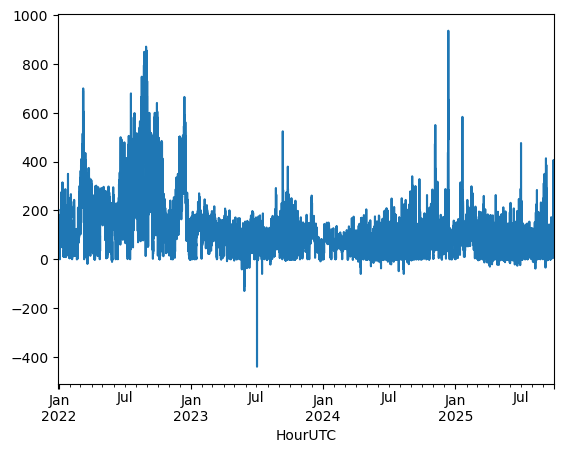

In [278]:
elspotprices["SpotPriceEUR"].plot()

<Axes: xlabel='HourUTC'>

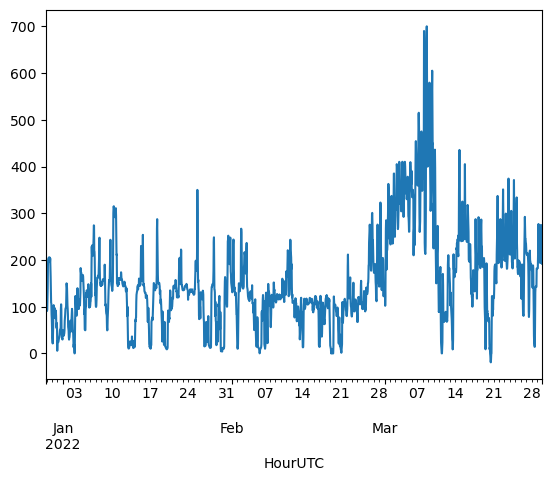

In [20]:
elspotprices["SpotPriceEUR"]["2021-12-28":"2022-3-29"].plot()

https://www.renewables.ninja/

In [21]:
# 1. Load the dataset
PV_data = pd.read_csv("Re_Ninja_PV_data_DK.csv", 
    skiprows=3, sep=None, engine='python',
    compression='infer')

# 2. Convert 'time' to datetime and remove timezone offset (+00:00)
# This makes it compatible with standard DK1/DK2 weather data
PV_data['time'] = pd.to_datetime(PV_data['time']).dt.tz_localize(None)

# 3. Set the index as a DatetimeIndex and drop the helper column
PV_data.index = pd.DatetimeIndex(PV_data['time'])
PV_data.drop(columns=['time'], inplace=True)

# 4. Clean column names (removes "Unnamed" or accidental whitespace)
PV_data.columns = PV_data.columns.str.strip()

# Display the first few rows to verify
print(PV_data.head())

                     DK01  DK02  DK03  DK04  DK05
time                                             
1980-01-01 00:00:00   0.0   0.0   0.0   0.0   0.0
1980-01-01 01:00:00   0.0   0.0   0.0   0.0   0.0
1980-01-01 02:00:00   0.0   0.0   0.0   0.0   0.0
1980-01-01 03:00:00   0.0   0.0   0.0   0.0   0.0
1980-01-01 04:00:00   0.0   0.0   0.0   0.0   0.0


<Axes: xlabel='time'>

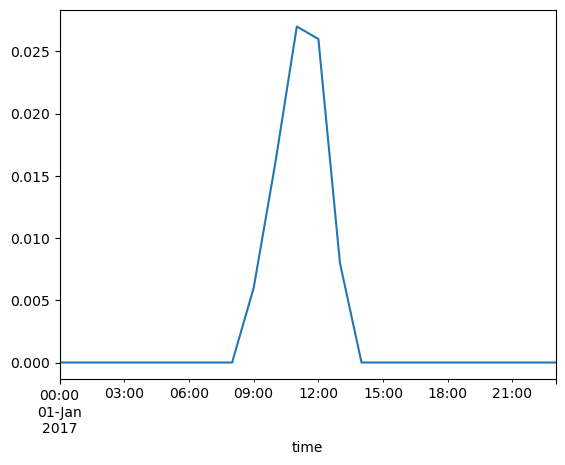

In [22]:
PV_data["DK01"]["2017-01-01"].plot()

<Axes: xlabel='utc_time'>

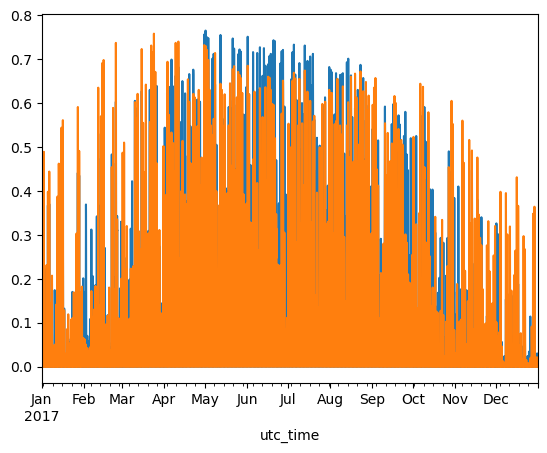

In [23]:
# Comparison between Solar Data Source
PV_data["DK01"]["2017-01-01":"2017-12-31"].plot()
solar_pv_data["DNK"]["2017-01-01":"2017-12-31"].plot()

In [24]:
OnshoreWind_Data = pd.read_csv("Re_Ninja_WindOnshore_data_DK.csv",
    skiprows=3, sep=None, engine='python',
    compression='infer')

OnshoreWind_Data["time"] = pd.to_datetime(OnshoreWind_Data["time"]).dt.tz_localize(None)
OnshoreWind_Data.index = pd.DatetimeIndex(OnshoreWind_Data["time"])
OnshoreWind_Data.drop(columns = ["time"], inplace = True)
OnshoreWind_Data.columns = OnshoreWind_Data.columns.str.strip()


print(OnshoreWind_Data.head())

                     NATIONAL      DK01      DK02      DK03      DK04  \
time                                                                    
1980-01-01 00:00:00  0.100020  0.169258  0.154797  0.058525  0.082945   
1980-01-01 01:00:00  0.095627  0.157692  0.155743  0.059855  0.076598   
1980-01-01 02:00:00  0.090815  0.145822  0.156026  0.060255  0.070185   
1980-01-01 03:00:00  0.082520  0.134984  0.153629  0.058150  0.058770   
1980-01-01 04:00:00  0.071892  0.122622  0.150896  0.054550  0.042691   

                         DK05  
time                           
1980-01-01 00:00:00  0.120442  
1980-01-01 01:00:00  0.112279  
1980-01-01 02:00:00  0.103703  
1980-01-01 03:00:00  0.092318  
1980-01-01 04:00:00  0.080078  


<Axes: xlabel='time'>

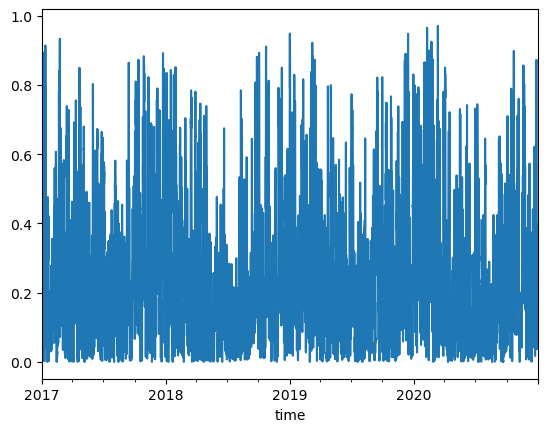

In [25]:
OnshoreWind_Data["DK01"]["2017-01-01":"2020-12-31"].plot()

<Axes: xlabel='utc_time'>

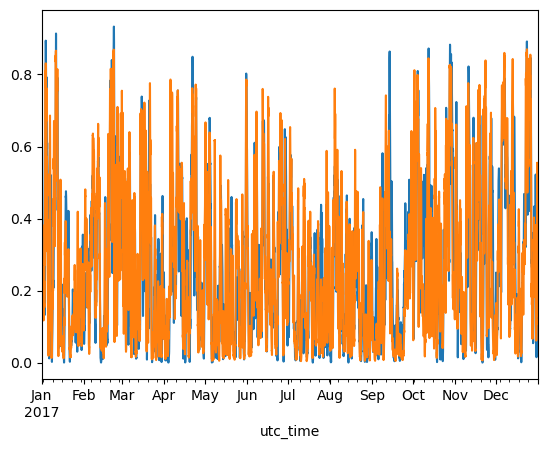

In [26]:
# Comparison between Wind data Source
OnshoreWind_Data["DK01"]["2017-01-01":"2017-12-31"].plot()
onshore_wind_data["DNK"]["2017-01-01":"2017-12-31"].plot()

In [376]:
PV_data["DK01"]

time
1980-01-01 00:00:00    0.0
1980-01-01 01:00:00    0.0
1980-01-01 02:00:00    0.0
1980-01-01 03:00:00    0.0
1980-01-01 04:00:00    0.0
                      ... 
2024-12-31 19:00:00    0.0
2024-12-31 20:00:00    0.0
2024-12-31 21:00:00    0.0
2024-12-31 22:00:00    0.0
2024-12-31 23:00:00    0.0
Name: DK01, Length: 394488, dtype: float64

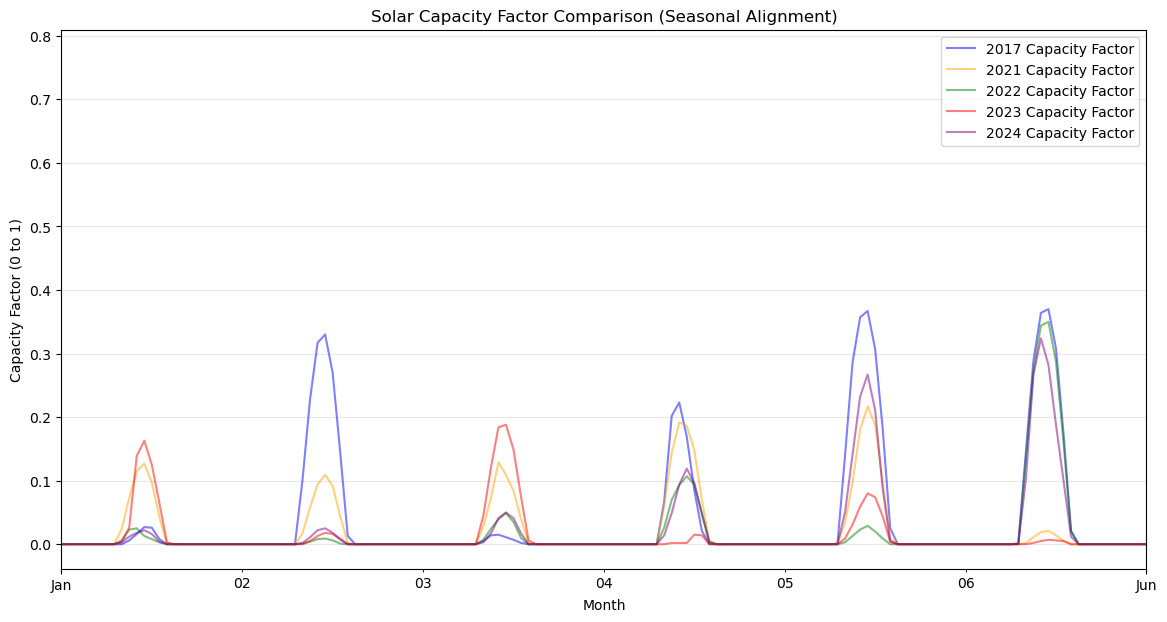

In [381]:
# 1. Extract the specific year data
pv_2017 = PV_data["DK01"]["2017"]
pv_2021 = PV_data["DK01"]["2021"]
pv_2022 = PV_data["DK01"]["2022"]
pv_2023 = PV_data["DK01"]["2023"]
pv_2024 = PV_data["DK01"]["2024"]
# Assuming you have 2025 data as well

# 2. Shift indices to overlap on the same X-axis (Year 2025)
# 2017 to 2025 = 8 years shift
pv_2017_shifted = pv_2017.copy()
pv_2017_shifted.index = pv_2017_shifted.index + pd.DateOffset(years=2025 - 2017)

pv_2022_shifted = pv_2022.copy()
pv_2022_shifted.index = pv_2022_shifted.index + pd.DateOffset(years=2025 - 2022)

pv_2023_shifted = pv_2023.copy()
pv_2023_shifted.index = pv_2023_shifted.index + pd.DateOffset(years=2025 - 2023)

pv_2024_shifted = pv_2024.copy()
pv_2024_shifted.index = pv_2024_shifted.index + pd.DateOffset(years=2025 - 2024)

# 2021 to 2025 = 4 years shift
pv_2021_shifted = pv_2021.copy()
pv_2021_shifted.index = pv_2021_shifted.index + pd.DateOffset(years=2025 - 2021)

# 3. Create the plot
plt.figure(figsize=(14, 7))

# Plotting with a slight transparency (alpha) so overlaps are visible
pv_2017_shifted.plot(label="2017 Capacity Factor", alpha=0.5, color='blue')
pv_2021_shifted.plot(label="2021 Capacity Factor", alpha=0.5, color='orange')
pv_2022_shifted.plot(label="2022 Capacity Factor", alpha=0.5, color='green')
pv_2023_shifted.plot(label="2023 Capacity Factor", alpha=0.5, color='red')
pv_2024_shifted.plot(label="2024 Capacity Factor", alpha=0.5, color='purple')
# 4. Styling the Axis
plt.title("Solar Capacity Factor Comparison (Seasonal Alignment)")
plt.ylabel("Capacity Factor (0 to 1)")
plt.xlabel("Month")
plt.xlim("2025-01-01", "2025-01-07")
plt.legend()
plt.grid(True, alpha=0.3)

# This makes the X-axis only show months since the year is now artificial
import matplotlib.dates as mdates
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b')) 

plt.show()

### Spot Price Data

In [27]:
DKK_Euro = 7.468  #https://www.ecb.europa.eu/stats/policy_and_exchange_rates/euro_reference_exchange_rates/html/eurofxref-graph-dkk.en.html

el_transmission_tariff = 4.3 / 100 * 1000 / DKK_Euro   # from energinet inputs in Ore/kWh DKK/MWh, bef 7.5
el_system_tariff = 7.2 / 100 * 1000 / DKK_Euro   # bef 5.1
el_afgift =  0.8 / 100 * 1000 / DKK_Euro         # bef 76.1 https://skm.dk/tal-og-metode/satser/satser-og-beloebsgraenser-i-lovgivningen/elafgiftsloven  https://elberegner.dk/guides/elafgift/
 
# DSO Tariff -  for 60/10kV transformer (A_low customer) #Staring from January 2026 https://n1.dk/elnetkunder/kommende-priser
el_net_tariff_low = 1.54  / 100 * 1000 / DKK_Euro   # Ore/kWh to eur/MWh
el_net_tariff_high = 4.63 / 100 * 1000 / DKK_Euro
el_net_tariff_peak = 9.27 / 100 * 1000 / DKK_Euro

VAT = 0.25 # 25 % VAT (Value Added Tax)

In [28]:
from types import SimpleNamespace

p = SimpleNamespace(

    # Model year (for defining summer/winter periods)
    En_price_year = 2017,

    # Full analysis period
    start_date = "2017-01-01",
    end_date   = "2018-01-01",

    # Fixed tariffs (constant every hour)
    el_transmission_tariff =  4.3 / 100 * 1000 / DKK_Euro , # 
    el_system_tariff       =  7.2 / 100 * 1000 / DKK_Euro,
    el_afgift              = 0.8 / 100 * 1000 / DKK_Euro   ,

    # Selling tariff (when exporting to grid)
    el_tariff_sell = (0.5 + 0.53)/100 * 1000 / DKK_Euro,  # Average of 0.5 and 0.53 DKK/kWh

    # Variable tariff levels
    el_net_tariff_low  = 1.54  / 100 * 1000 / DKK_Euro,
    el_net_tariff_high = 4.63 / 100 * 1000 / DKK_Euro,
    el_net_tariff_peak = 9.27 / 100 * 1000 / DKK_Euro
)

# 2. PRICE CALCULATION FUNCTION
# ============================================================
def build_electricity_grid_price_w_tariff(Elspotprices):
    """
    Inputs:
        Elspotprices : pd.Series indexed by DatetimeIndex (HourUTC)
    Output:
        (final_grid_buy_price, grid_sell_price)
    """
    # ---- Base buy price (fixed tariffs only) ----
    base_price = (Elspotprices
        + p.el_transmission_tariff
        + p.el_system_tariff
        + p.el_afgift)

    # ---- Grid selling price ----
    sell_price = -Elspotprices + p.el_tariff_sell

    # Use timestamps directly from your Series
    hours = Elspotprices.index

    # ---- SUMMER ----
    summer_start = pd.Timestamp(f"{p.En_price_year}-04-01 00:00", tz=hours.tz)
    summer_end   = pd.Timestamp(f"{p.En_price_year}-10-01 00:00", tz=hours.tz)

    summer = hours[(hours >= summer_start) & (hours < summer_end)]

    # ---- WINTER = all other hours ----
    winter = hours.difference(summer)

    # Remove Feb 29
    winter = winter[~((winter.month == 2) & (winter.day == 29))]

    # ---- Tariff rules ----
    peak_hours          = range(7, 22)     # 06–21
    high_wd_winter      = range(22, 25)    # 21–23
    high_we_winter      = range(7, 25)     # 06–23
    high_wd_summer      = range(7, 25)     # 06–23

    # ---- Tariff decision function ----
    def tariff(h):
        wd = h.weekday()   # 0=Mon … 6=Sun
        hr = h.hour

        if h in winter:
            # WINTER
            if wd >= 5:  # weekend
                return p.el_net_tariff_high if hr in high_we_winter else p.el_net_tariff_low
            else:
                if hr in peak_hours:
                    return p.el_net_tariff_peak
                elif hr in high_wd_winter:
                    return p.el_net_tariff_high
                else:
                    return p.el_net_tariff_low

        else:
            # SUMMER
            if wd >= 5:  # weekend
                return p.el_net_tariff_low
            else:
                return p.el_net_tariff_high if hr in high_wd_summer else p.el_net_tariff_low

    # ---- Hourly tariff series ----
    tariffs = pd.Series({h: tariff(h) for h in hours})

    # ---- Final buy price ----
    final_price = base_price + tariffs

    return final_price, sell_price

In [29]:
Elspotprices = DK1_data_2017["DK1_EUR/MWh"]

# Compute grid prices
grid_buy_price, grid_sell_price = build_electricity_grid_price_w_tariff(Elspotprices)

<Axes: xlabel='HourUTC'>

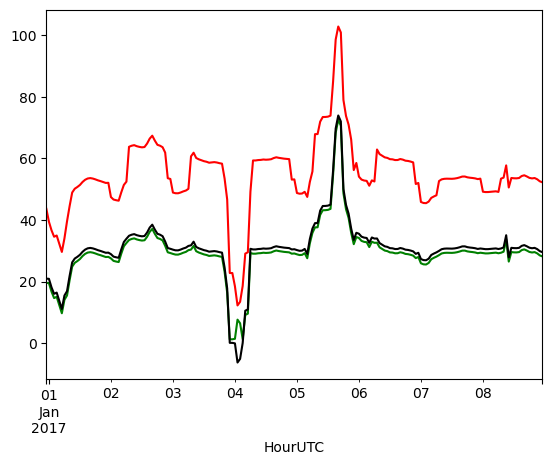

In [30]:
grid_buy_price["2016-12-31 23:00:00":"2017-01-08 23:00:00"].plot(color = "red")

#---- Similar Magnitudes, just the tariffs added-----------------
abs(grid_sell_price["2016-12-31 23:00:00":"2017-01-08 23:00:00"]).plot(color = "green")
Elspotprices["2016-12-31 23:00:00":"2017-01-08 23:00:00"].plot(color = "black")


In [31]:
costs.at["battery storage", "capital_cost"]/(5000*0.9)

2.8794729710597164

- Revenue from selling Heat from Rondo
- Revenue from electrcity

### Initialisation of Model and Components

In [32]:
import pandas as pd

def get_time_period(start='2017-01-01', end='2017-12-31', freq='h', tz_naive=True):
    """
    Generates a pandas DatetimeIndex for a specified period.
    
    Args:
        start (str): Start date/time (e.g., '2017-01-01' or '2017-01-01 00:00Z')
        end (str): End date/time
        freq (str): Frequency (default 'h' for hourly)
        tz_naive (bool): If True, removes timezone info (localized to None)
        
    Returns:
        pd.DatetimeIndex
    """
    # Create the range
    dr = pd.date_range(start=start, end=end, freq=freq)
    
    # Strip timezone if requested
    if tz_naive and dr.tz is not None:
        dr = dr.tz_localize(None)
    elif tz_naive and dr.tz is None:
        # Even if not localized, ensure it's naive if strings had offsets
        dr = dr.tz_localize(None)
        
    return dr

In [33]:
# 1. Replicating your 2017 logic
time_period_2017 = get_time_period('2017-01-01 00:00Z', '2017-12-30 22:00Z', freq = "h")

time_period_2017

DatetimeIndex(['2017-01-01 00:00:00', '2017-01-01 01:00:00',
               '2017-01-01 02:00:00', '2017-01-01 03:00:00',
               '2017-01-01 04:00:00', '2017-01-01 05:00:00',
               '2017-01-01 06:00:00', '2017-01-01 07:00:00',
               '2017-01-01 08:00:00', '2017-01-01 09:00:00',
               ...
               '2017-12-30 13:00:00', '2017-12-30 14:00:00',
               '2017-12-30 15:00:00', '2017-12-30 16:00:00',
               '2017-12-30 17:00:00', '2017-12-30 18:00:00',
               '2017-12-30 19:00:00', '2017-12-30 20:00:00',
               '2017-12-30 21:00:00', '2017-12-30 22:00:00'],
              dtype='datetime64[ns]', length=8735, freq=None)

In [34]:

p = SimpleNamespace(
    # Fixed tariffs (constant every hour)
    el_transmission_tariff =  4.3 / 100 * 1000 / DKK_Euro , # 
    el_system_tariff       =  7.2 / 100 * 1000 / DKK_Euro,
    el_afgift              = 0.8 / 100 * 1000 / DKK_Euro   ,

    # Selling tariff (when exporting to grid)
    el_tariff_sell = (0.5 + 0.53)/100 * 1000 / DKK_Euro,  # Average of 0.5 and 0.53 DKK/kWh

    # Variable tariff levels
    el_net_tariff_low  = 1.54  / 100 * 1000 / DKK_Euro,
    el_net_tariff_high = 4.63 / 100 * 1000 / DKK_Euro,
    el_net_tariff_peak = 9.27 / 100 * 1000 / DKK_Euro
)

In [35]:
import pandas as pd

def build_electricity_grid_price_w_tariff(Elspotprices,p ,year):
    """
    Calculates prices for a specific YEAR by filtering the input data.
    """
    # 1. ---- SELECT THE YEAR ----
    # This filters the index so we only calculate for the year we want
    year_str = str(year)
    Elspotprices = Elspotprices[year_str].copy()
    
    if Elspotprices.empty:
        raise ValueError(f"No data available in Elspotprices for the year {year}")

    # 2. ---- BASE CALCULATIONS ----
    base_price = (Elspotprices
        + p.el_transmission_tariff
        + p.el_system_tariff
        + p.el_afgift)

    # Grid selling price (revenue is often positive in PyPSA, 
    # remove the minus if your bus logic requires it)
    sell_price = -Elspotprices + p.el_tariff_sell

    hours = Elspotprices.index

    # 3. ---- SEASONAL DEFINITIONS ----
    # Use the 'year' argument to define the periods correctly
    summer_start = pd.Timestamp(year=year, month=4, day=1, hour=0).tz_localize(hours.tz)
    summer_end   = pd.Timestamp(year=year, month=10, day=1, hour=0).tz_localize(hours.tz)

    # Create boolean masks for summer/winter (much faster than .difference)
    is_summer = (hours >= summer_start) & (hours < summer_end)
    is_winter = ~is_summer

    # 4. ---- TARIFF RULES ----
    # Radius/Cerius standard Danish time-of-use windows
    peak_hours      = range(17, 21)    # 17–21 (Cooking peak)
    high_wd_winter  = range(6, 24)     # 06-17 and 21-24 are high (excluding peak)
    high_we_winter  = range(6, 24)     # 06–24
    high_wd_summer  = range(6, 24)     # 06–24

    # 5. ---- TARIFF DECISION LOGIC ----
    def tariff(h):
        wd = h.weekday()   # 0=Mon … 6=Sun
        hr = h.hour
        
        if is_winter[hours.get_loc(h)]:
            # WINTER
            if wd >= 5:  # Weekend
                return p.el_net_tariff_high if hr in high_we_winter else p.el_net_tariff_low
            else:        # Weekday
                if hr in peak_hours:
                    return p.el_net_tariff_peak
                elif hr in high_wd_winter:
                    return p.el_net_tariff_high
                else:
                    return p.el_net_tariff_low
        else:
            # SUMMER
            if wd >= 5:  # Weekend
                return p.el_net_tariff_low
            else:        # Weekday
                return p.el_net_tariff_high if hr in high_wd_summer else p.el_net_tariff_low

    # 6. ---- APPLY AND RETURN ----
    tariffs = pd.Series({h: tariff(h) for h in hours})
    buy_price = base_price + tariffs

    return buy_price, sell_price

In [36]:
buy_price22, sell_price22 = build_electricity_grid_price_w_tariff(elspotprices["SpotPriceEUR"],p,year = 2022)

In [37]:
elspotprices["SpotPriceEUR"]["2022"]

HourUTC
2022-01-01 00:00:00    41.330002
2022-01-01 01:00:00    43.220001
2022-01-01 02:00:00    45.459999
2022-01-01 03:00:00    37.669998
2022-01-01 04:00:00    39.700001
                         ...    
2022-12-31 19:00:00    40.500000
2022-12-31 20:00:00    14.890000
2022-12-31 21:00:00     9.940000
2022-12-31 22:00:00     4.840000
2022-12-31 23:00:00     2.010000
Name: SpotPriceEUR, Length: 8760, dtype: float64

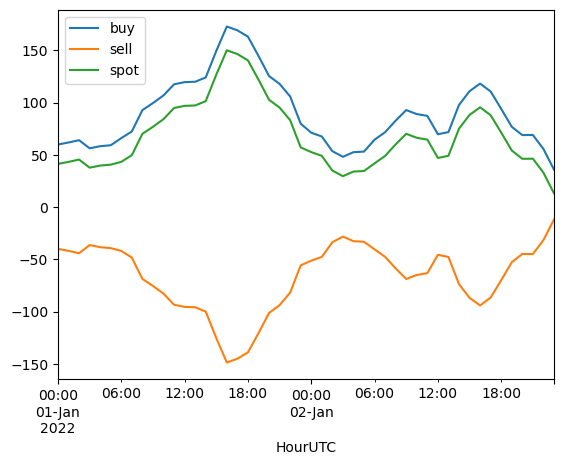

In [38]:
buy_price22[0:24*2].plot(label = "buy")
sell_price22[0:24*2].plot(label = "sell")
elspotprices["SpotPriceEUR"]["2022"][0:24*2].plot(label = "spot")
plt.legend()

In [39]:
time_period = get_time_period('2023-01-01 00:00Z', '2023-12-31 23:00Z', freq = "h")
time_period

DatetimeIndex(['2023-01-01 00:00:00', '2023-01-01 01:00:00',
               '2023-01-01 02:00:00', '2023-01-01 03:00:00',
               '2023-01-01 04:00:00', '2023-01-01 05:00:00',
               '2023-01-01 06:00:00', '2023-01-01 07:00:00',
               '2023-01-01 08:00:00', '2023-01-01 09:00:00',
               ...
               '2023-12-31 14:00:00', '2023-12-31 15:00:00',
               '2023-12-31 16:00:00', '2023-12-31 17:00:00',
               '2023-12-31 18:00:00', '2023-12-31 19:00:00',
               '2023-12-31 20:00:00', '2023-12-31 21:00:00',
               '2023-12-31 22:00:00', '2023-12-31 23:00:00'],
              dtype='datetime64[ns]', length=8760, freq=None)

- we only have full dataset years for 2023 onwards

In [40]:
"Spot Price Data";
price_import23, price_export23 = build_electricity_grid_price_w_tariff(elspotprices["SpotPriceEUR"],p,year = 2023)

"Capacity Factor Wind";
CF_w23 = OnshoreWind_Data["DK01"]["2023"]

"Capacity Factor Solar";
CF_s23 = PV_data["DK01"]["2023"]

"Natural Gas Price";
NG_price23 = gas_price_hourly["MarginalPurchasePriceEUR_MWh"]["2023"]


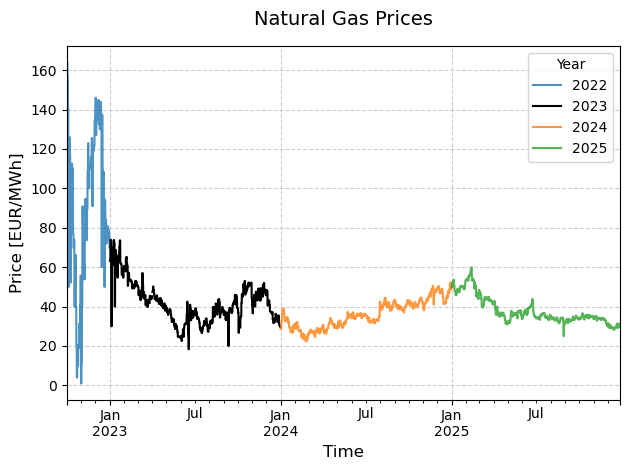

In [41]:
import matplotlib.pyplot as plt

# Plotting with labels for the legend
gas_price_hourly["MarginalPurchasePriceEUR_MWh"]["2022"].plot(label="2022", alpha=0.8)
NG_price23.plot(color="black", label="2023", linewidth=1.5)
gas_price_hourly["MarginalPurchasePriceEUR_MWh"]["2024"].plot(label="2024", alpha=0.8)
gas_price_hourly["MarginalPurchasePriceEUR_MWh"]["2025"].plot(label="2025", alpha=0.8)

# Adding Descriptive Labels and Title
plt.title("Natural Gas Prices", fontsize=14, pad=15)
plt.xlabel("Time", fontsize=12)
plt.ylabel("Price [EUR/MWh]", fontsize=12)

# Adding Legend and Grid for readability
plt.legend(title="Year", loc="best", frameon=True)
plt.grid(True, linestyle="--", alpha=0.6)

# Final formatting
plt.tight_layout()
plt.savefig("gas_price_comparison.png")

https://www.worlddata.info/europe/denmark/inflation-rates.php

In [335]:
def get_inflation_multiplier(inflation_rates, start_year, end_year=2025):
    """
    Calculates the cumulative inflation multiplier.
    
    :param inflation_rates: Dictionary {year: rate_as_decimal} 
                            Example: {2022: 0.085} for 8.5%
    :param start_year: The year your data starts (e.g., 2020)
    :param end_year: The target year (default 2025)
    :return: Cumulative multiplier as a float
    """
    multiplier = 1.0
    
    # Loop through the years and compound the rates
    for year in range(start_year, end_year + 1):
        rate = inflation_rates.get(year, 0)  # Use 0 if the year isn't in your data
        multiplier *= (1 + rate)
        
    return multiplier

In [272]:
# Historical Annual Inflation Rate
my_rates = {
    2020: 0.003,
    2021: 0.019,
    2022: 0.085,
    2023: 0.034,
    2024: 0.018,
    2025: 0.019
}

In [297]:
elspotprices["SpotPriceEUR"]["2024"] 

HourUTC
2024-01-01 00:00:00    28.139999
2024-01-01 01:00:00    26.660000
2024-01-01 02:00:00     4.140000
2024-01-01 03:00:00    -0.030000
2024-01-01 04:00:00    -0.020000
                         ...    
2024-12-31 19:00:00    19.000000
2024-12-31 20:00:00    15.700000
2024-12-31 21:00:00     9.060000
2024-12-31 22:00:00     0.520000
2024-12-31 23:00:00     2.160000
Name: SpotPriceEUR, Length: 8784, dtype: float64

<Axes: xlabel='GasDay'>

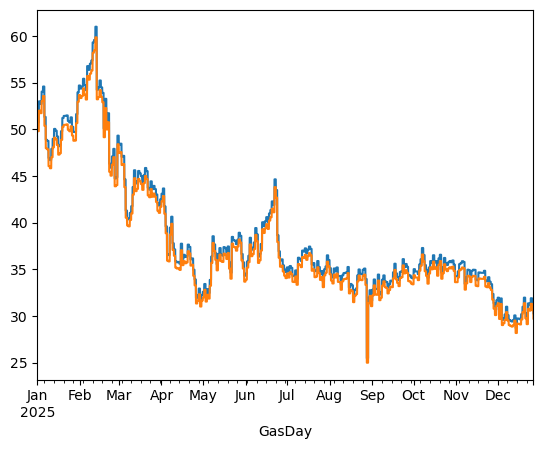

In [323]:
gas_price_2025_adj.plot()
gas_price_hourly["MarginalPurchasePriceEUR_MWh"]["2025"].plot()


<Axes: xlabel='GasDay'>

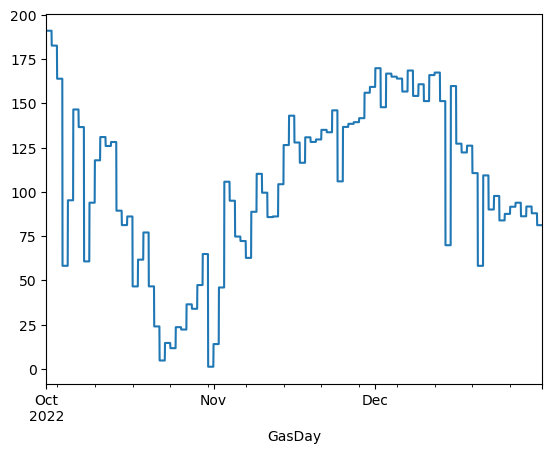

In [368]:
(gas_price_hourly["MarginalPurchasePriceEUR_MWh"]["2022"]*get_inflation_multiplier(my_rates, start_year=2022, end_year=2025)).plot()

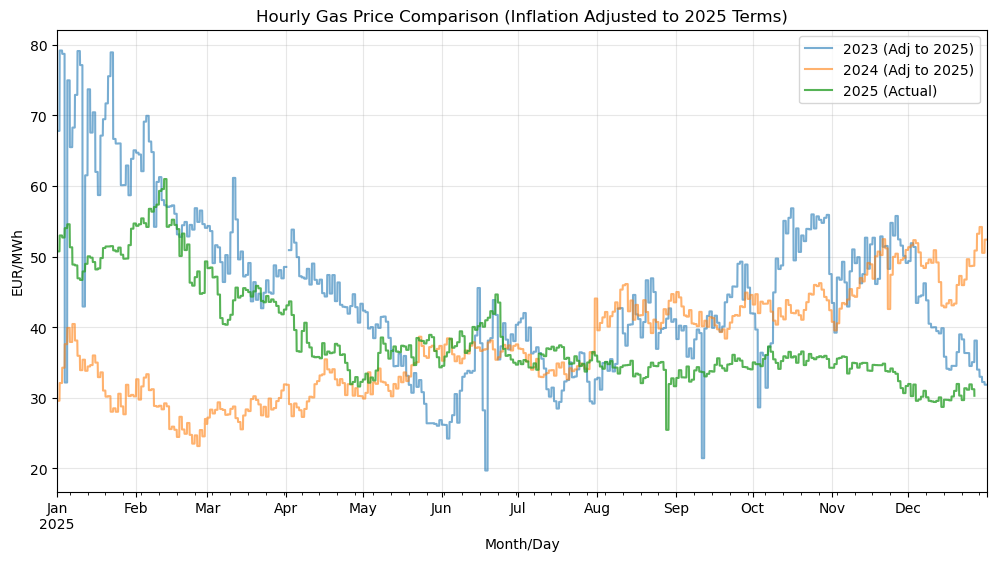

In [333]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Calculate adjusted prices
# Note: Multiplying 2025 by its own rate assumes you want the price at the END of 2025 terms.
gas_price_2023_adj = gas_price_hourly["MarginalPurchasePriceEUR_MWh"]["2023"] * get_inflation_multiplier(my_rates, start_year=2023, end_year=2025)
gas_price_2024_adj = gas_price_hourly["MarginalPurchasePriceEUR_MWh"]["2024"] * get_inflation_multiplier(my_rates, start_year=2024, end_year=2025)
gas_price_2025_adj = gas_price_hourly["MarginalPurchasePriceEUR_MWh"]["2025"] * get_inflation_multiplier(my_rates, start_year=2025, end_year=2025)

# 2. Shift indices to overlap on the X-axis
# Use pd.DateOffset(years=n) instead of Timedelta
gas_price_2023_shifted = gas_price_2023_adj.copy()
gas_price_2023_shifted.index = gas_price_2023_shifted.index + pd.DateOffset(years=2)

gas_price_2024_shifted = gas_price_2024_adj.copy()
gas_price_2024_shifted.index = gas_price_2024_shifted.index + pd.DateOffset(years=1)

# For 2025, no shift is needed, but we keep the naming consistent
gas_price_2025_shifted = gas_price_2025_adj.copy()

# 3. Create the plot
plt.figure(figsize=(12, 6))

# Use alpha to see overlaps better if lines are dense
gas_price_2023_shifted.plot(label="2023 (Adj to 2025)", alpha=0.6)
gas_price_2024_shifted.plot(label="2024 (Adj to 2025)", alpha=0.6)
gas_price_2025_shifted.plot(label="2025 (Actual)", alpha=0.8)

plt.title("Hourly Gas Price Comparison (Inflation Adjusted to 2025 Terms)")
plt.ylabel("EUR/MWh")
plt.xlabel("Month/Day")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<Axes: xlabel='HourUTC'>

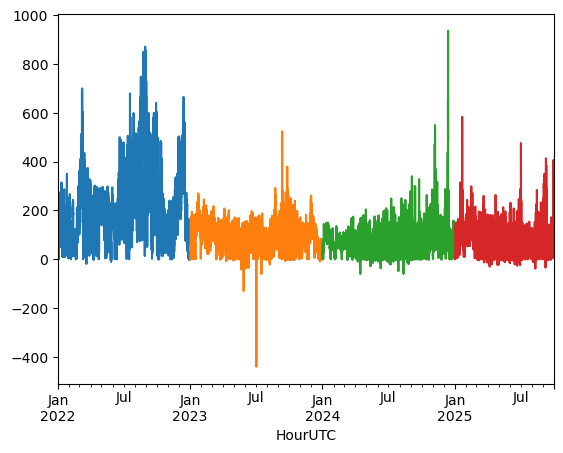

In [350]:
elspotprices["SpotPriceEUR"]["2022"].plot()
elspotprices["SpotPriceEUR"]["2023"].plot()
elspotprices["SpotPriceEUR"]["2024"].plot()
elspotprices["SpotPriceEUR"]["2025"].plot()


In [352]:
elspotprices["SpotPriceEUR"]["2025"]

HourUTC
2025-01-01 00:00:00      1.600000
2025-01-01 01:00:00      1.630000
2025-01-01 02:00:00      1.090000
2025-01-01 03:00:00      0.470000
2025-01-01 04:00:00      0.000000
                          ...    
2025-09-30 17:00:00    357.769989
2025-09-30 18:00:00    147.279999
2025-09-30 19:00:00    116.040001
2025-09-30 20:00:00    101.629997
2025-09-30 21:00:00     92.540001
Name: SpotPriceEUR, Length: 6550, dtype: float64

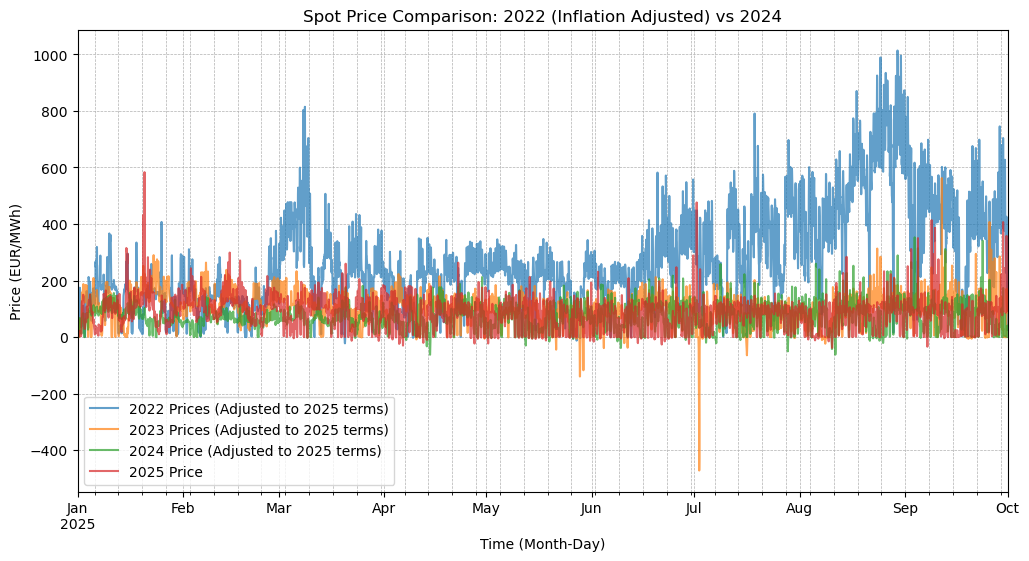

In [ ]:
price_2022_adj = elspotprices["SpotPriceEUR"]["2022"] * get_inflation_multiplier(my_rates, start_year=2022, end_year=2025)
price_2023_adj = elspotprices["SpotPriceEUR"]["2023"] * get_inflation_multiplier(my_rates, start_year=2023, end_year=2025)
price_2024_adj = elspotprices["SpotPriceEUR"]["2024"] * get_inflation_multiplier(my_rates, start_year=2024, end_year=2025)

# Get the 2025 prices
price_2025 = elspotprices["SpotPriceEUR"]["2025"]

# 2. Shift the 2022 index so it overlaps with 2025
# This moves the timestamps forward by 3 years
price_2022_shifted = price_2022_adj.copy()
price_2022_shifted.index = price_2022_shifted.index + pd.DateOffset(years=3)

price_2023_shifted = price_2023_adj.copy()
price_2023_shifted.index = price_2023_shifted.index + pd.DateOffset(years=2)

price_2024_shifted = price_2024_adj.copy()
price_2024_shifted.index = price_2024_shifted.index + pd.DateOffset(years=1)

# 3. Create the plot
plt.figure(figsize=(12, 6))

# Plot both Series on the same axis
price_2022_shifted.plot(label="2022 Prices (Adjusted to 2025 terms)", alpha=0.7)
price_2023_shifted.plot(label="2023 Prices (Adjusted to 2025 terms)", alpha=0.7)
price_2024_shifted.plot(label="2024 Price (Adjusted to 2025 terms)", alpha=0.7)
price_2025.plot(label="2025 Price", alpha=0.7)

# Add styling
plt.title("Spot Price Comparison: Inflation Adjusted for 2025")
plt.ylabel("Price (EUR/MWh)")
plt.xlabel("Time (Month-Day)")
#plt.ylim(-500,500)
plt.xlim("2025-01-01", "2025-10-01")
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

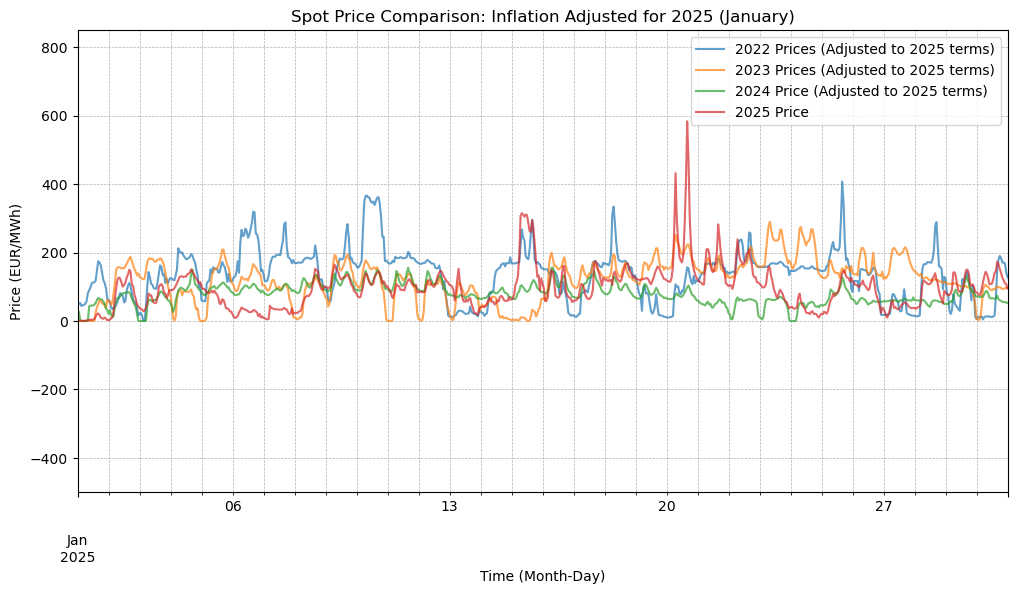

In [364]:

# 3. Create the plot
plt.figure(figsize=(12, 6))

# Plot both Series on the same axis
price_2022_shifted.plot(label="2022 Prices (Adjusted to 2025 terms)", alpha=0.7)
price_2023_shifted.plot(label="2023 Prices (Adjusted to 2025 terms)", alpha=0.7)
price_2024_shifted.plot(label="2024 Price (Adjusted to 2025 terms)", alpha=0.7)
price_2025.plot(label="2025 Price", alpha=0.7)

# Add styling
plt.title("Spot Price Comparison: Inflation Adjusted for 2025 (January)")
plt.ylabel("Price (EUR/MWh)")
plt.xlabel("Time (Month-Day)")
#plt.ylim(-500,500)
plt.xlim("2025-01-01", "2025-01-31")
plt.legend()
plt.ylim(-500,850)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

In [276]:
get_inflation_multiplier(my_rates, start_year=2023, end_year=2025)

1.072611628

In [42]:
def add_carriers(n):
    #n.add("Carrier",'electricity grid im')
    #n.add("Carrier","electricity grid ex") 
    n.add("Carrier","onshorewind")
    n.add("Carrier","solar")
    #n.add("Carrier","electric boiler")
    #n.add("Carrier","Rondo charge")
    #n.add("Carrier","Rondo store")
    #n.add("Carrier","Rondo discharge")
    n.add("Carrier","heat")
    #n.add("Carrier","battery storage")
    n.add("Carrier","electricity")
    n.add("Carrier","gas") # co2_emissions=0.206tonnes/MWh   # for NG boiler # Assume that methane gas emits 0.198 tCO2 per MWh of thermal energy contained in the gas. 
    n.add("Carrier", "pellets") 
    n.add("Carrier", "CO2") #co2_emissions=-0.164 (tCO2/MWh_pell) #for biochar # -0.164 ????
    n.add("Carrier", "pyrolysis")

In [43]:

costs.at["solar", "capital_cost"]

51346.82981964593

In [44]:
def add_skive_generators(n,p_PPA):

    # EuroWind Owns These Assets
    n.add("Generator", "Skive_Solar", carrier="solar",
        bus = "EuroWind" ,
        capital_cost=costs.at["solar", "capital_cost"],
        marginal_cost=costs.at["solar", "marginal_cost"], 
        p_max_pu= CF_s23.values, 
        p_nom = 36)


    n.add("Generator","Skive_Onshore_Wind", carrier="onshorewind",
        bus = "EuroWind",
        capital_cost=costs.at["onwind", "capital_cost"],
        marginal_cost=costs.at["onwind", "marginal_cost"],
        p_max_pu= CF_w23.values,
        p_nom = 54)

    #--------------------------------
    # PPA link
    n.add("Link", "PPA",
          bus0="EuroWind",
          bus1="Greenlab",
          p_nom_extendable=True,
          efficiency=0.97,
          p_min_pu=0,
          p_max_pu=1.0,
          carrier="electricity",
          marginal_cost=p_PPA)

In [45]:
def add_grid(n, price_import, price_export):
    #------ IMPORTS ----------------------------
    n.add("Generator", "Grid_Generator",
          bus="Grid_Import",
          p_nom_extendable=True,
          efficiency=1.0,
          marginal_cost=5e-6,
          capital_cost=0.0,
          carrier="electricity")

    n.add("Link", "Imports",
          bus0="Grid_Import",
          bus1="EuroWind",
          p_nom=84,
          p_nom_extendable=False,
          efficiency=0.97,
          p_min_pu=0,
          p_max_pu=1.0,
          carrier="electricity",
          marginal_cost=price_import)

    #------- EXPORTS -----------------------
    n.add("Store", "Grid_Store",
          bus="Grid_Export",
          e_nom_extendable=True,
          capital_cost=0.0,
          standing_loss=0.0,
          carrier="electricity")

    n.add("Link", "Exports",
          bus0="EuroWind",
          bus1="Grid_Export",
          p_nom=84,
          p_nom_extendable=False,
          efficiency=0.97,
          p_min_pu=0,
          p_max_pu=1.0,
          carrier="electricity",
          marginal_cost=price_export)

    

In [46]:
# Assuming that EuroWind will do all the balancing and Ancillarly Services and

def add_battery(n,P_nom, max_t, cyclic_operation = True):
    n.add("StorageUnit",
        "Skive_Battery",
        bus="EuroWind",  # Use your electricity bus name
        carrier="battery storage",
        max_hours= max_t,  # 22 MW * 2 h = 44 MWh
        capital_cost=costs.at["battery inverter", "capital_cost"] + 4 * costs.at["battery storage", "capital_cost"],
        efficiency_store = 0.90, # Charging Efficiency
        efficiency_dispatch=costs.at["battery inverter", "efficiency"], # Discharging Efficiency
        p_nom= P_nom,  # 22 MW
        p_nom_extendable=False,
        cyclic_state_of_charge=cyclic_operation)

In [47]:
"High Temprature Bus (350)";
def add_TES_rondo(n,e_nom_store = 100, p_nom_charge= 24,p_nom_discharge = 7):
    n.add("Store", "Rondo_Concrete_Heat_Storage",
        bus="TES_Rondo",
        e_nom= e_nom_store, # MWh
        e_nom_extendable=False,
        e_initial=0,
        e_cyclic=True,
        standing_loss= 1.2/100, # 1.2% per hour
        capital_cost=costs.at["Concrete-store", "capital_cost"] )      

    # "Charging of Rondo ,  El_Bus -> TES_Rondo";
    n.add("Link",
        "El_to_TES_Rondo",
        bus0="Greenlab",
        bus1="TES_Rondo",
        p_nom_extendable=False,
        p_nom = p_nom_charge, # MW
        efficiency=0.98,
        carrier = "electricity",
        capital_cost=costs.at["Concrete-charger", "capital_cost"])

    # "Discharging of Rondo , TES_Rondo -> Heat_Bus_Skive";
    n.add("Link",
        "TES_Rondo_to_Heat_Bus_Skive",
        bus0="TES_Rondo",
        bus1="Heat_Exchanger_Bus",
        p_nom = p_nom_discharge,
        p_nom_extendable=False,
        efficiency=0.90,
        capital_cost=costs.at["Concrete-discharger", "capital_cost"])

In [48]:
# 2 Heat Exchanger hence effincecy = 0.9*0.9 = 0.81
def add_heat_exchanger(n):
    n.add("Link", "Heat_Exchanger_Rondo",
     bus0="Heat_Exchanger_Bus",
     bus1="Heat_MT", 
     carrier="heat", 
     p_nom_extendable=True , 
     efficiency=0.8)

In [49]:
"Medium Temprature (150 C)";
def  add_electric_boiler(n):
    "Boiler at Skive";
    n.add("Link","Boiler_Skive",
        bus0 = "Greenlab",
        bus1="Heat_MT",
        p_nom = 10, # MW
        efficiency=0.9,
        carrier = "electric boiler",
        capital_cost=costs.at["electric boiler steam","capital_cost"])

In [50]:
# DH_Price = 40 - 60 EUR/MWh
def add_heat_load(n,p_load,DH_cost):

    n.add("Link","MT_Heat_Supply",
        bus0="Heat_MT",
        bus1="Heat_Sink",
        p_nom_extendable=True,
        carrier = "heat",
        marginal_cost = -DH_cost,) # MWh

    n.add("Load", "Skive_Heat_Load", 
        bus="Heat_Sink",
        p_nom_extendable=False,
        carrier = "heat",
        p_set = p_load) # MWh

In [51]:
def add_NG_boiler(n,CO2tax):
     n.add("Generator",
        "NG grid",
        bus="NG",
        carrier="gas",
        p_nom = 6,
        marginal_cost = NG_price23 + CO2tax, #0.206  tCO2/MWh *  80EUR/tC02 + VOM 1.007EUR/MWh
        p_nom_extendable=False,)

     n.add("Link","NG boiler",
        bus0="NG",
        bus1="Heat_MT",
        efficiency=0.98,
        p_nom=6,
        p_nom_extendable=False,
        capital_cost=5772) 
    

In [52]:
def add_SkyClean(n,CO2tax):  
    n.add("Generator",
        "pellets input",
        bus="pellets",
        carrier="pellets",
        p_nom_extendable=True,
        marginal_cost= 62) #€/MWh (Price of straw pellets 380 €/t
    
    n.add("Link",
        "pyrolysis",
        bus0="pellets",
        bus1="Heat_MT",
        bus2="Greenlab",
        bus3="biochar",
        efficiency= 3.7859/7.6748, #"biochar pyrolysis", "heat output" (MWh_th/t_CO2)/ "biochar pyrolysis", "biomass input (MWh_biomass/t_CO2), #bus1 devided by bus0.
        efficiency2= -0.3184/7.6748,   #-"biochar pyrolysis", "electricity input"] (MWh_e/t_CO2) / "biochar pyrolysis", "biomass input"(MWh_biomass/t_CO2),
        efficiency3=  1/7.6748,  #1 / "biochar pyrolysis", "biomass input,
        marginal_cost= 2.5909/7.6748, #"biomass HOP", "VOM" (EUR/MWh)/ "biochar pyrolysis", "biomass input"(MWh_biomass/t_CO2)? #     
        p_nom_extendable=False,
        p_nom=2,
        carrier="pyrolysis",
        capital_cost=233477) 

    
    n.add("Link",
        "biochar sequestration",
        bus0="biochar",
        bus1="biochar sequestration",
        efficiency=1,
        p_nom_extendable = True,
        marginal_cost=-0.164*CO2tax,   #CO2 tax   or -0.164 (tCO2/MWh_pell)?  # -1  * co2_credits #-13.12eur/MWh
        carrier="CO2") 

    n.add(
        "Store",
        "biochar sequestred",
        bus="biochar sequestration",
        e_nom_extendable=True,
        e_cyclic=False,
        carrier="CO2")

In [53]:
3.7859 + 2.5909 + 1.301

7.6777999999999995

In [54]:
#Fixed demand
def add_el_load(n,p_el):
    "Adding the Localised Demand in Greenlab Skive";
    n.add("Load",  "Skive_el_Load", 
        bus="Greenlab", 
        p_set= p_el,
        carrier = "electricity") #MWh

In [55]:
# Index(['Heat_Exchanger_Bus', 'TES_Rondo', 'Heat_MT', 'Heat_Sink'], dtype='object', name='Bus')

In [61]:
def build_network(P_el,P_heat,CO2_tax1, CO2_tax2,p_import,p_export,p_PPA,horizon):
     
    n = pypsa.Network()
    hours = get_time_period('2023-01-01 00:00Z', '2023-12-31 23:00Z', freq = "h")
    n.set_snapshots(hours)

    add_carriers(n)

    n.add("Bus", "Greenlab", carrier = "electricity")
    n.add("Bus", "EuroWind", carrier = "electricity")
    n.add("Bus", "Grid_Import", carrier = "electricity")
    n.add("Bus", "Grid_Export", carrier = "electricity")
    
    n.add("Bus", "Heat_Exchanger_Bus", carrier = "heat")
    n.add("Bus","TES_Rondo", carrier = "heat")
    n.add("Bus", "Heat_MT", carrier = "heat")
    n.add("Bus","Heat_Sink", carrier = "heat")

    n.add("Bus", "NG", carrier = "gas")
    n.add("Bus", "pellets", carrier="pellets")
    n.add("Bus", "biochar", carrier="CO2")
    n.add("Bus", "biochar sequestration", carrier="CO2")


    add_battery(n,P_nom = 22, max_t = 2, cyclic_operation = True)
    add_skive_generators(n, p_PPA) # 90 EUR/MWh
    add_grid(n,p_import,p_export)

    add_el_load(n,P_el)
    add_heat_load(n,P_heat,DH_cost = 0) # 50 EUR/MWh

    
    add_TES_rondo(n,e_nom_store = 100, p_nom_charge= 24,p_nom_discharge = 7)
    add_heat_exchanger(n)
    add_electric_boiler(n)
    add_NG_boiler(n,CO2_tax1)
    add_SkyClean(n,CO2_tax2)

    #print(n.consistency_check())
    # 3. Optimize and return the actual network object 'n'
    status = n.optimize(solver_name="gurobi")
    
    n.optimize.optimize_with_rolling_horizon(horizon=horizon, overlap=0,log_to_console=False)

    return n


In [123]:
len(price_import23)

8760

In [80]:
"3 Weeks Horizion";
n_3w = build_network(P_el = 2,P_heat = 5, CO2_tax1 = 80, CO2_tax2 = 80,p_import=price_import23 ,p_export=price_export23,p_PPA = 90, horizon = 24*7*3) 

Index(['Skive_Battery'], dtype='object', name='StorageUnit')
Index(['Boiler_Skive'], dtype='object', name='Link')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 10/10 [00:00<00:00, 14.40it/s]
INFO:linopy.io: Writing time: 4.82s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2745017


INFO:gurobipy:Set parameter LicenseID to value 2745017


...

INFO:gurobipy:


Solved in 16454 iterations and 5.36 seconds (0.93 work units)


INFO:gurobipy:Solved in 16454 iterations and 5.36 seconds (0.93 work units)


Optimal objective -3.734006970e+06


INFO:gurobipy:Optimal objective -3.734006970e+06
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 219008 primals, 525608 duals
Objective: -3.73e+06
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-fix-e-lower, Store-fix-e-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.
INFO:pypsa.optimization.abstract:Optimizing network for snapshot horizon [2023-01-01 00:00:00:2023-01-21 23:00:00] (1/18).
Index(['Skive_Battery'], dtype='o

In [ ]:
"1 Week Horizon";
n_1w = build_network(P_el = 2,P_heat = 5, CO2_tax1 = 80, CO2_tax2 = 80,p_import=price_import23 ,p_export=price_export23,p_PPA = 90, horizon = 24*7*1)

Index(['Skive_Battery'], dtype='object', name='StorageUnit')
Index(['Boiler_Skive'], dtype='object', name='Link')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 10/10 [00:00<00:00, 13.89it/s]
INFO:linopy.io: Writing time: 4.9s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2745017


INFO:gurobipy:Set parameter LicenseID to value 2745017


...

INFO:gurobipy:


Solved in 16454 iterations and 5.39 seconds (0.93 work units)


INFO:gurobipy:Solved in 16454 iterations and 5.39 seconds (0.93 work units)


Optimal objective -3.734006970e+06


INFO:gurobipy:Optimal objective -3.734006970e+06
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 219008 primals, 525608 duals
Objective: -3.73e+06
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-fix-e-lower, Store-fix-e-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.
INFO:pypsa.optimization.abstract:Optimizing network for snapshot horizon [2023-01-01 00:00:00:2023-01-07 23:00:00] (1/53).
Index(['Skive_Battery'], dtype='o

In [126]:
"Rolling Horizon 1 Day";
n_1d = build_network(P_el = 2,P_heat = 5, CO2_tax1 = 80, CO2_tax2 = 80,p_import=price_import23 ,p_export=price_export23,p_PPA = 90, horizon = 24*1)

Index(['Skive_Battery'], dtype='object', name='StorageUnit')
Index(['Boiler_Skive'], dtype='object', name='Link')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 10/10 [00:00<00:00, 13.73it/s]
INFO:linopy.io: Writing time: 5.07s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2745017


INFO:gurobipy:Set parameter LicenseID to value 2745017


...

INFO:gurobipy:


Solved in 16454 iterations and 5.24 seconds (0.93 work units)


INFO:gurobipy:Solved in 16454 iterations and 5.24 seconds (0.93 work units)


Optimal objective -3.734006970e+06


INFO:gurobipy:Optimal objective -3.734006970e+06
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 219008 primals, 525608 duals
Objective: -3.73e+06
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-fix-e-lower, Store-fix-e-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.
INFO:pypsa.optimization.abstract:Optimizing network for snapshot horizon [2023-01-01 00:00:00:2023-01-01 23:00:00] (1/365).
Index(['Skive_Battery'], dtype='

In [158]:
"Rolling Horizon 3 Days";
n_3d = build_network(P_el = 2,P_heat = 5, CO2_tax1 = 80, CO2_tax2 = 80,p_import=price_import23 ,p_export=price_export23,p_PPA = 90, horizon = 24*3)

Index(['Skive_Battery'], dtype='object', name='StorageUnit')
Index(['Boiler_Skive'], dtype='object', name='Link')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 10/10 [00:00<00:00, 14.15it/s]
INFO:linopy.io: Writing time: 4.86s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2745017


INFO:gurobipy:Set parameter LicenseID to value 2745017


...

INFO:gurobipy:


Solved in 16454 iterations and 5.29 seconds (0.93 work units)


INFO:gurobipy:Solved in 16454 iterations and 5.29 seconds (0.93 work units)


Optimal objective -3.734006970e+06


INFO:gurobipy:Optimal objective -3.734006970e+06
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 219008 primals, 525608 duals
Objective: -3.73e+06
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-fix-e-lower, Store-fix-e-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.
INFO:pypsa.optimization.abstract:Optimizing network for snapshot horizon [2023-01-01 00:00:00:2023-01-03 23:00:00] (1/122).
Index(['Skive_Battery'], dtype='

In [150]:
"Rolling Horizon 3 Months";
n_3m = build_network(P_el = 2,P_heat = 5, CO2_tax1 = 80, CO2_tax2 = 80,p_import=price_import23 ,p_export=price_export23,p_PPA = 90, horizon = 2190)

Index(['Skive_Battery'], dtype='object', name='StorageUnit')
Index(['Boiler_Skive'], dtype='object', name='Link')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 10/10 [00:00<00:00, 13.74it/s]
INFO:linopy.io: Writing time: 5.09s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2745017


INFO:gurobipy:Set parameter LicenseID to value 2745017


...

INFO:gurobipy:


Solved in 16454 iterations and 5.39 seconds (0.93 work units)


INFO:gurobipy:Solved in 16454 iterations and 5.39 seconds (0.93 work units)


Optimal objective -3.734006970e+06


INFO:gurobipy:Optimal objective -3.734006970e+06
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 219008 primals, 525608 duals
Objective: -3.73e+06
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-fix-e-lower, Store-fix-e-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.
INFO:pypsa.optimization.abstract:Optimizing network for snapshot horizon [2023-01-01 00:00:00:2023-04-02 05:00:00] (1/4).
Index(['Skive_Battery'], dtype='ob

In [128]:
"Perfect Foresight"
n_full = build_network(P_el = 2,P_heat = 5, CO2_tax1 = 80, CO2_tax2 = 80,p_import=price_import23 ,p_export=price_export23,p_PPA = 90, horizon = 8760)

Index(['Skive_Battery'], dtype='object', name='StorageUnit')
Index(['Boiler_Skive'], dtype='object', name='Link')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 10/10 [00:00<00:00, 13.80it/s]
INFO:linopy.io: Writing time: 5.0s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2745017


INFO:gurobipy:Set parameter LicenseID to value 2745017


...

INFO:gurobipy:


Solved in 16454 iterations and 5.22 seconds (0.93 work units)


INFO:gurobipy:Solved in 16454 iterations and 5.22 seconds (0.93 work units)


Optimal objective -3.734006970e+06


INFO:gurobipy:Optimal objective -3.734006970e+06
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 219008 primals, 525608 duals
Objective: -3.73e+06
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-fix-e-lower, Store-fix-e-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.
INFO:pypsa.optimization.abstract:Optimizing network for snapshot horizon [2023-01-01 00:00:00:2023-12-31 23:00:00] (1/1).
Index(['Skive_Battery'], dtype='ob

In [160]:
n_1d.objective,n_3d.objective,n_1w.objective, n_3w.objective,n_3m.objective ,n_full.objective

(5381.761326725342,
 5883.819793225101,
 5381.761326725342,
 27657.5549581049,
 -390785.4308360058,
 -3734006.969916704)

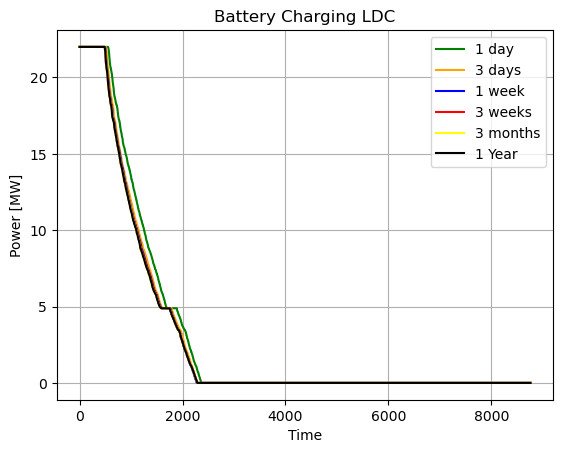

In [167]:
p_charge_1d = np.sort(n_1d.storage_units_t.p_store["Skive_Battery"])[::-1]
plt.plot(p_charge_1d, color = "green", label = "1 day")

p_charge_3d = np.sort(n_3d.storage_units_t.p_store["Skive_Battery"])[::-1]
plt.plot(p_charge_3d, color = "orange", label = "3 days")

p_charge_1w = np.sort(n_1w.storage_units_t.p_store["Skive_Battery"])[::-1]
plt.plot(p_charge_1w, color = "blue", label = "1 week")

p_charge_3w = np.sort(n_3w.storage_units_t.p_store["Skive_Battery"])[::-1]
plt.plot(p_charge_3w, color = "red", label = "3 weeks")

p_charge_3m = np.sort(n_3m.storage_units_t.p_store["Skive_Battery"])[::-1]
plt.plot(p_charge_3m, color = "yellow", label = "3 months")

p_charge_full = np.sort(n_full.storage_units_t.p_store["Skive_Battery"])[::-1]
plt.plot(p_charge_full, color = "black", label = "1 Year")

plt.legend()
plt.title("Battery Charging LDC")
plt.xlabel("Time")
plt.grid()
plt.ylabel("Power [MW]")
plt.show()

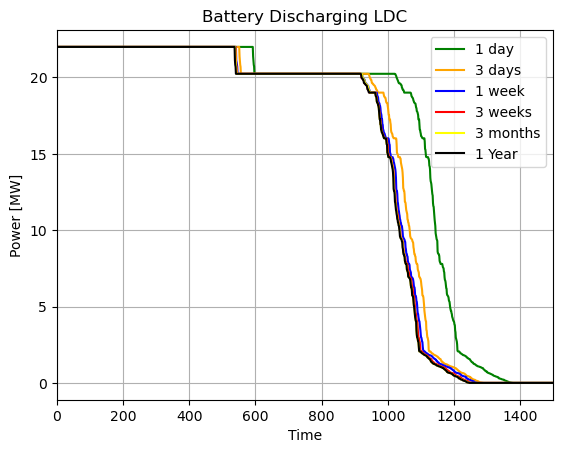

In [169]:
p_discharge_1d = np.sort(n_1d.storage_units_t.p_dispatch["Skive_Battery"])[::-1]
plt.plot(p_discharge_1d, color = "green", label = "1 day")

p_discharge_3d = np.sort(n_3d.storage_units_t.p_dispatch["Skive_Battery"])[::-1]
plt.plot(p_discharge_3d, color = "orange", label = "3 days")

p_discharge_1w = np.sort(n_1w.storage_units_t.p_dispatch["Skive_Battery"])[::-1]
plt.plot(p_discharge_1w, color = "blue", label = "1 week")

p_discharge_3w = np.sort(n_3w.storage_units_t.p_dispatch["Skive_Battery"])[::-1]
plt.plot(p_discharge_3w, color = "red", label = "3 weeks")

p_discharge_3m = np.sort(n_3m.storage_units_t.p_dispatch["Skive_Battery"])[::-1]
plt.plot(p_discharge_3m, color = "yellow", label = "3 months")

p_discharge_full = np.sort(n_full.storage_units_t.p_dispatch["Skive_Battery"])[::-1]
plt.plot(p_discharge_full, color = "black", label = "1 Year")

plt.legend()
plt.title("Battery Discharging LDC")
plt.xlabel("Time")
plt.grid()
plt.ylabel("Power [MW]")
plt.xlim(0,1500)
plt.show()

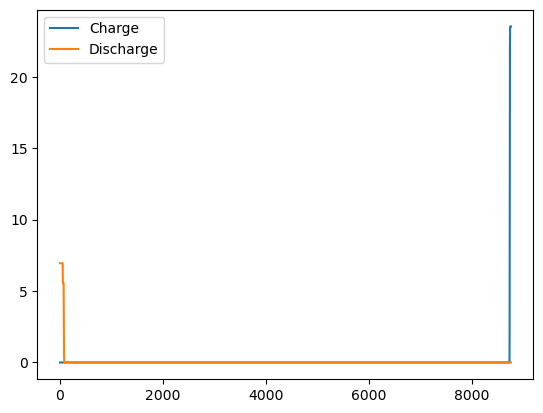

In [ ]:
"Heat Charging for Rondo";
n_full.links_t.p1["El_to_TES_Rondo"]
"Heat Discharging for Rondo";
n_full.links_t.p0["TES_Rondo_to_Heat_Bus_Skive"]


p_charge_rondo_full = -np.sort(n_3d.links_t.p1["El_to_TES_Rondo"])[::-1]
p_discharge_rondo_full = np.sort(n_3d.links_t.p0["TES_Rondo_to_Heat_Bus_Skive"])[::-1]

plt.plot(p_charge_rondo_full, label="Charge")
plt.plot(p_discharge_rondo_full, label="Discharge")
plt.legend()
plt.show()

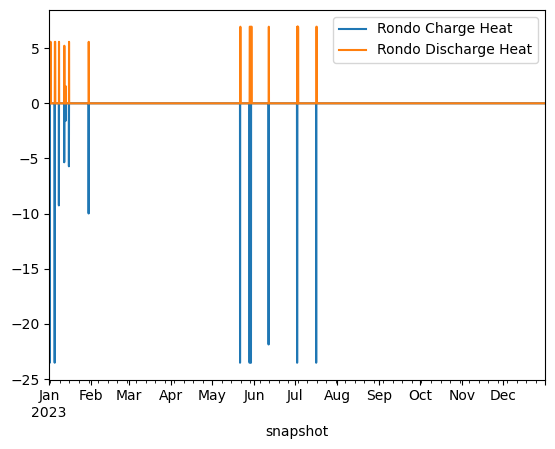

In [261]:
n_full.links_t.p1["El_to_TES_Rondo"].plot(label ="Rondo Charge Heat")
n_full.links_t.p0["TES_Rondo_to_Heat_Bus_Skive"].plot(label ="Rondo Discharge Heat")

plt.legend()

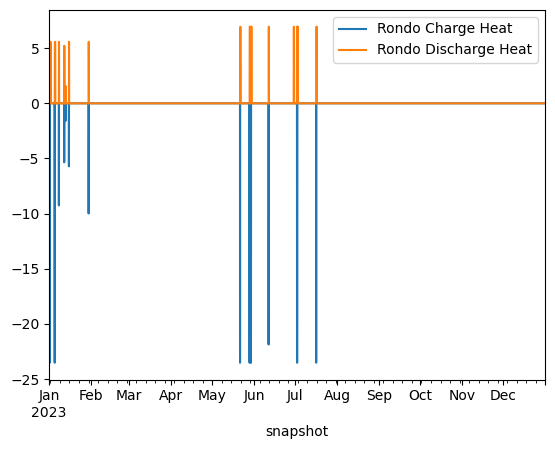

In [262]:
n_3d.links_t.p1["El_to_TES_Rondo"].plot(label ="Rondo Charge Heat")
n_3d.links_t.p0["TES_Rondo_to_Heat_Bus_Skive"].plot(label ="Rondo Discharge Heat")
plt.legend()


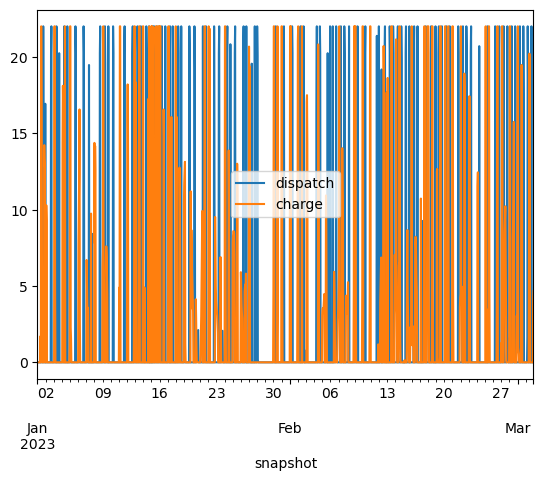

In [252]:
n_3d.storage_units_t.p_dispatch["Skive_Battery"]["2023-01-01":"2023-03-02"].plot(label="dispatch")
n_3d.storage_units_t.p_store["Skive_Battery"]["2023-01-01":"2023-03-02"].plot(label="charge")
plt.legend()

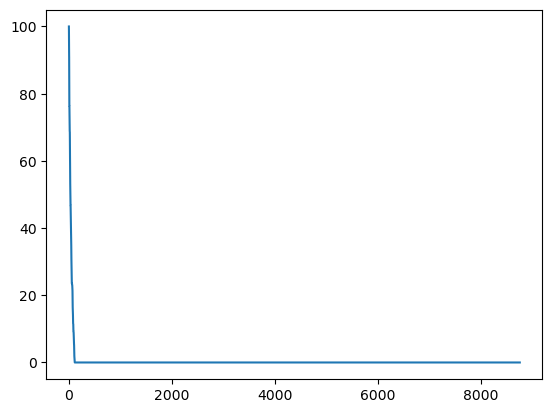

In [240]:
e_RONDO_n_full = np.sort(n_3d.stores_t.e['Rondo_Concrete_Heat_Storage'])[::-1]
plt.plot(e_RONDO_n_full)

<Axes: xlabel='snapshot'>

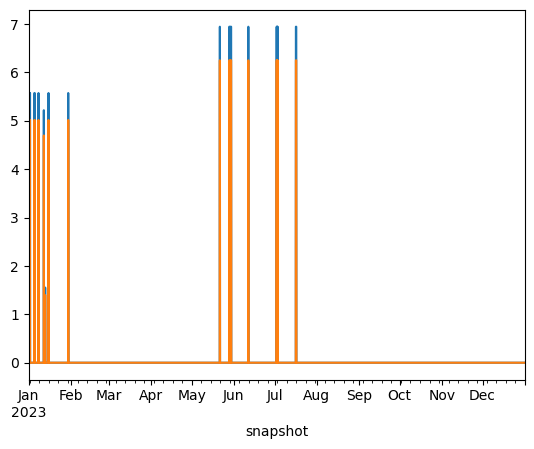

In [191]:
n_full.links_t.p0["TES_Rondo_to_Heat_Bus_Skive"].plot()
(-n_full.links_t.p1["TES_Rondo_to_Heat_Bus_Skive"]).plot()

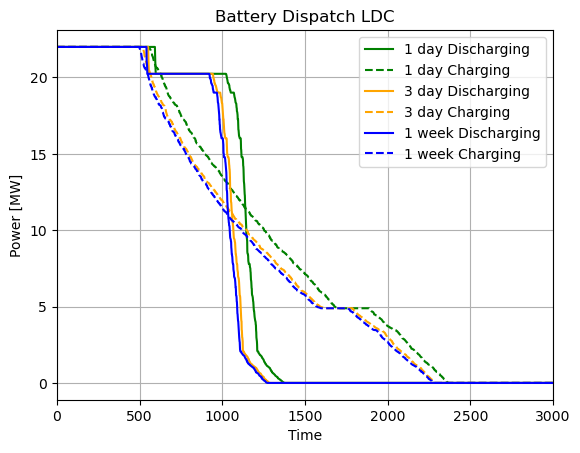

In [177]:
plt.plot(p_discharge_1d, color = "green", label = "1 day Discharging")
plt.plot(p_charge_1d, color = "green", label = "1 day Charging", linestyle = "--")
plt.plot(p_discharge_3d, color = "orange", label = "3 day Discharging")
plt.plot(p_charge_3d, color = "orange", label = "3 day Charging", linestyle = "--")
plt.plot(p_discharge_1w, color = "blue", label = "1 week Discharging")
plt.plot(p_charge_1w, color = "blue", label = "1 week Charging", linestyle = "--")
plt.legend()
plt.title("Battery Dispatch LDC")
plt.xlabel("Time")
plt.grid()
plt.ylabel("Power [MW]")
plt.xlim(0,3000)
plt.show()


### Sensitivty Analysis

In [61]:
# --- 2. DEFINE THE STATS FUNCTION ---
def get_sensitivity_stats(network_list, prefix="sens"):
    all_totals = []
    for i, n in enumerate(network_list):
        # Sum OPEX and CAPEX shadow prices for total marginal system cost
        totex = n.statistics.opex().sum() + n.statistics.capex().sum()
        all_totals.append(totex)
    return pd.Series(all_totals, index=relative_change)

In [125]:
# --- 1. SET BASELINES ---
BASE_TAX = 80
BASE_EL_LOAD = 13
BASE_HEAT_LOAD = 10
Base_PPA = 90 

p_import_base = price_import23.copy() 
p_export_base = price_export23.copy()

In [126]:
sens_scale = np.array([0.9,0.95,1,1.05,1.1])
relative_change = (sens_scale - 1) * 100  # Converts [0.9, 1.1] to [-10%, +10%]

In [127]:
# TimeSeries Sensitivty Input
p_import_scenarios = [p_import_base * factor for factor in sens_scale]
p_export_scenarios = [p_export_base * factor for factor in sens_scale]

In [128]:
n_sens_CO2 = []
for tax in (BASE_TAX * sens_scale):
    n = build_network(P_el=BASE_EL_LOAD, P_heat=BASE_HEAT_LOAD, 
                      CO2_tax1=tax, CO2_tax2=tax,
                      p_import=p_import_base, p_export=p_export_base,p_PPA = Base_PPA)
    n_sens_CO2.append(n)

Index(['Heat_Exchanger_Bus', 'TES_Rondo', 'Heat_MT', 'Heat_Sink'], dtype='object', name='Bus')
Index(['Skive_Heat_Load'], dtype='object', name='Load')
Index(['MT_Heat_Supply', 'TES_Rondo_to_Heat_Bus_Skive',
       'Heat_Exchanger_Rondo'],
      dtype='object', name='Link')
Index(['Rondo_Concrete_Heat_Storage'], dtype='object', name='Store')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 10/10 [00:00<00:00, 14.18it/s]
INFO:linopy.io: Writing time: 4.87s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2745017


INFO:gurobipy:Set parameter LicenseID to value 2745017


...

INFO:gurobipy:


Solved in 41088 iterations and 5.31 seconds (1.13 work units)


INFO:gurobipy:Solved in 41088 iterations and 5.31 seconds (1.13 work units)


Optimal objective  2.253551908e+07


INFO:gurobipy:Optimal objective  2.253551908e+07
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 219008 primals, 525608 duals
Objective: 2.25e+07
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-fix-e-lower, Store-fix-e-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.


In [129]:
n_sens_heat = []
for heat in (BASE_HEAT_LOAD*sens_scale):
    n = build_network(P_el=BASE_EL_LOAD, P_heat=heat, 
                      CO2_tax1=BASE_TAX, CO2_tax2=BASE_TAX,
                      p_import=p_import_base, p_export=p_export_base, p_PPA = Base_PPA)
    n_sens_heat.append(n)

Index(['Heat_Exchanger_Bus', 'TES_Rondo', 'Heat_MT', 'Heat_Sink'], dtype='object', name='Bus')
Index(['Skive_Heat_Load'], dtype='object', name='Load')
Index(['MT_Heat_Supply', 'TES_Rondo_to_Heat_Bus_Skive',
       'Heat_Exchanger_Rondo'],
      dtype='object', name='Link')
Index(['Rondo_Concrete_Heat_Storage'], dtype='object', name='Store')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 10/10 [00:00<00:00, 13.22it/s]
INFO:linopy.io: Writing time: 5.09s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2745017


INFO:gurobipy:Set parameter LicenseID to value 2745017


...

INFO:gurobipy:


Solved in 37862 iterations and 5.35 seconds (1.09 work units)


INFO:gurobipy:Solved in 37862 iterations and 5.35 seconds (1.09 work units)


Optimal objective  2.401677661e+07


INFO:gurobipy:Optimal objective  2.401677661e+07
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 219008 primals, 525608 duals
Objective: 2.40e+07
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-fix-e-lower, Store-fix-e-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.


In [130]:
n_sens_p_import = []
for p_import in (p_import_scenarios):
    n = build_network(P_el=BASE_EL_LOAD, P_heat=BASE_HEAT_LOAD, 
                      CO2_tax1=BASE_TAX, CO2_tax2=BASE_TAX,
                      p_import=p_import, p_export=p_export_base, p_PPA = Base_PPA)
    n_sens_p_import.append(n)

Index(['Heat_Exchanger_Bus', 'TES_Rondo', 'Heat_MT', 'Heat_Sink'], dtype='object', name='Bus')
Index(['Skive_Heat_Load'], dtype='object', name='Load')
Index(['MT_Heat_Supply', 'TES_Rondo_to_Heat_Bus_Skive',
       'Heat_Exchanger_Rondo'],
      dtype='object', name='Link')
Index(['Rondo_Concrete_Heat_Storage'], dtype='object', name='Store')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 10/10 [00:00<00:00, 13.41it/s]
INFO:linopy.io: Writing time: 5.14s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2745017


INFO:gurobipy:Set parameter LicenseID to value 2745017


...

INFO:gurobipy:


Solved in 42233 iterations and 5.41 seconds (1.13 work units)


INFO:gurobipy:Solved in 42233 iterations and 5.41 seconds (1.13 work units)


Optimal objective  2.255286456e+07


INFO:gurobipy:Optimal objective  2.255286456e+07
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 219008 primals, 525608 duals
Objective: 2.26e+07
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-fix-e-lower, Store-fix-e-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.


In [131]:
n_sens_p_export = []
for p_export in (p_export_scenarios):
    n = build_network(P_el=BASE_EL_LOAD, P_heat=BASE_HEAT_LOAD, 
                      CO2_tax1=BASE_TAX, CO2_tax2=BASE_TAX,
                      p_import=p_import_base, p_export=p_export,p_PPA = Base_PPA)
    n_sens_p_export.append(n)


Index(['Heat_Exchanger_Bus', 'TES_Rondo', 'Heat_MT', 'Heat_Sink'], dtype='object', name='Bus')
Index(['Skive_Heat_Load'], dtype='object', name='Load')
Index(['MT_Heat_Supply', 'TES_Rondo_to_Heat_Bus_Skive',
       'Heat_Exchanger_Rondo'],
      dtype='object', name='Link')
Index(['Rondo_Concrete_Heat_Storage'], dtype='object', name='Store')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 10/10 [00:00<00:00, 13.14it/s]
INFO:linopy.io: Writing time: 5.15s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2745017


INFO:gurobipy:Set parameter LicenseID to value 2745017


...

INFO:gurobipy:


Solved in 41448 iterations and 5.46 seconds (1.13 work units)


INFO:gurobipy:Solved in 41448 iterations and 5.46 seconds (1.13 work units)


Optimal objective  2.178908712e+07


INFO:gurobipy:Optimal objective  2.178908712e+07
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 219008 primals, 525608 duals
Objective: 2.18e+07
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-fix-e-lower, Store-fix-e-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.


In [132]:
n_sens_PPA = []
for PPA in (Base_PPA*sens_scale):
    n = build_network(P_el=BASE_EL_LOAD, P_heat=BASE_HEAT_LOAD, 
                      CO2_tax1=BASE_TAX, CO2_tax2=BASE_TAX,
                      p_import=p_import_base, p_export=p_export_base,p_PPA = PPA)
    n_sens_PPA.append(n)

Index(['Heat_Exchanger_Bus', 'TES_Rondo', 'Heat_MT', 'Heat_Sink'], dtype='object', name='Bus')
Index(['Skive_Heat_Load'], dtype='object', name='Load')
Index(['MT_Heat_Supply', 'TES_Rondo_to_Heat_Bus_Skive',
       'Heat_Exchanger_Rondo'],
      dtype='object', name='Link')
Index(['Rondo_Concrete_Heat_Storage'], dtype='object', name='Store')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 10/10 [00:00<00:00, 12.92it/s]
INFO:linopy.io: Writing time: 5.02s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2745017


INFO:gurobipy:Set parameter LicenseID to value 2745017


...

INFO:gurobipy:


Solved in 41106 iterations and 5.34 seconds (1.12 work units)


INFO:gurobipy:Solved in 41106 iterations and 5.34 seconds (1.12 work units)


Optimal objective  2.355447317e+07


INFO:gurobipy:Optimal objective  2.355447317e+07
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 219008 primals, 525608 duals
Objective: 2.36e+07
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-fix-e-lower, Store-fix-e-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.


In [138]:
n_sens_el = []
for el in (BASE_EL_LOAD*sens_scale):
    n = build_network(P_el=el, P_heat=BASE_HEAT_LOAD, 
                      CO2_tax1=BASE_TAX, CO2_tax2=BASE_TAX,
                      p_import=p_import_base, p_export=p_export_base,p_PPA = Base_PPA)
    n_sens_el.append(n)


Index(['Heat_Exchanger_Bus', 'TES_Rondo', 'Heat_MT', 'Heat_Sink'], dtype='object', name='Bus')
Index(['Skive_Heat_Load'], dtype='object', name='Load')
Index(['MT_Heat_Supply', 'TES_Rondo_to_Heat_Bus_Skive',
       'Heat_Exchanger_Rondo'],
      dtype='object', name='Link')
Index(['Rondo_Concrete_Heat_Storage'], dtype='object', name='Store')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 10/10 [00:00<00:00, 13.19it/s]
INFO:linopy.io: Writing time: 4.96s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2745017


INFO:gurobipy:Set parameter LicenseID to value 2745017


...

INFO:gurobipy:


Solved in 41501 iterations and 5.53 seconds (1.13 work units)


INFO:gurobipy:Solved in 41501 iterations and 5.53 seconds (1.13 work units)


Optimal objective  2.437311037e+07


INFO:gurobipy:Optimal objective  2.437311037e+07
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 219008 primals, 525608 duals
Objective: 2.44e+07
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-fix-e-lower, Store-fix-e-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.


In [133]:
n_sens_heat

[PyPSA Network 'Unnamed Network'
 -------------------------------
 Components:
  - Bus: 12
  - Carrier: 16
  - Generator: 5
  - Link: 11
  - Load: 2
  - StorageUnit: 1
  - Store: 3
 Snapshots: 8760,
 PyPSA Network 'Unnamed Network'
 -------------------------------
 Components:
  - Bus: 12
  - Carrier: 16
  - Generator: 5
  - Link: 11
  - Load: 2
  - StorageUnit: 1
  - Store: 3
 Snapshots: 8760,
 PyPSA Network 'Unnamed Network'
 -------------------------------
 Components:
  - Bus: 12
  - Carrier: 16
  - Generator: 5
  - Link: 11
  - Load: 2
  - StorageUnit: 1
  - Store: 3
 Snapshots: 8760,
 PyPSA Network 'Unnamed Network'
 -------------------------------
 Components:
  - Bus: 12
  - Carrier: 16
  - Generator: 5
  - Link: 11
  - Load: 2
  - StorageUnit: 1
  - Store: 3
 Snapshots: 8760,
 PyPSA Network 'Unnamed Network'
 -------------------------------
 Components:
  - Bus: 12
  - Carrier: 16
  - Generator: 5
  - Link: 11
  - Load: 2
  - StorageUnit: 1
  - Store: 3
 Snapshots: 8760]

In [134]:
n_sens_CO2

[PyPSA Network 'Unnamed Network'
 -------------------------------
 Components:
  - Bus: 12
  - Carrier: 16
  - Generator: 5
  - Link: 11
  - Load: 2
  - StorageUnit: 1
  - Store: 3
 Snapshots: 8760,
 PyPSA Network 'Unnamed Network'
 -------------------------------
 Components:
  - Bus: 12
  - Carrier: 16
  - Generator: 5
  - Link: 11
  - Load: 2
  - StorageUnit: 1
  - Store: 3
 Snapshots: 8760,
 PyPSA Network 'Unnamed Network'
 -------------------------------
 Components:
  - Bus: 12
  - Carrier: 16
  - Generator: 5
  - Link: 11
  - Load: 2
  - StorageUnit: 1
  - Store: 3
 Snapshots: 8760,
 PyPSA Network 'Unnamed Network'
 -------------------------------
 Components:
  - Bus: 12
  - Carrier: 16
  - Generator: 5
  - Link: 11
  - Load: 2
  - StorageUnit: 1
  - Store: 3
 Snapshots: 8760,
 PyPSA Network 'Unnamed Network'
 -------------------------------
 Components:
  - Bus: 12
  - Carrier: 16
  - Generator: 5
  - Link: 11
  - Load: 2
  - StorageUnit: 1
  - Store: 3
 Snapshots: 8760]

In [140]:
spider_data = pd.DataFrame({
    "CO2 - tax": get_sensitivity_stats(n_sens_CO2),
    "P_heat": get_sensitivity_stats(n_sens_heat),
    "Price Import": get_sensitivity_stats(n_sens_p_import),
    "Price Export": get_sensitivity_stats(n_sens_p_export),
    "PPA price": get_sensitivity_stats(n_sens_PPA),
    "P_el": get_sensitivity_stats(n_sens_el),
})

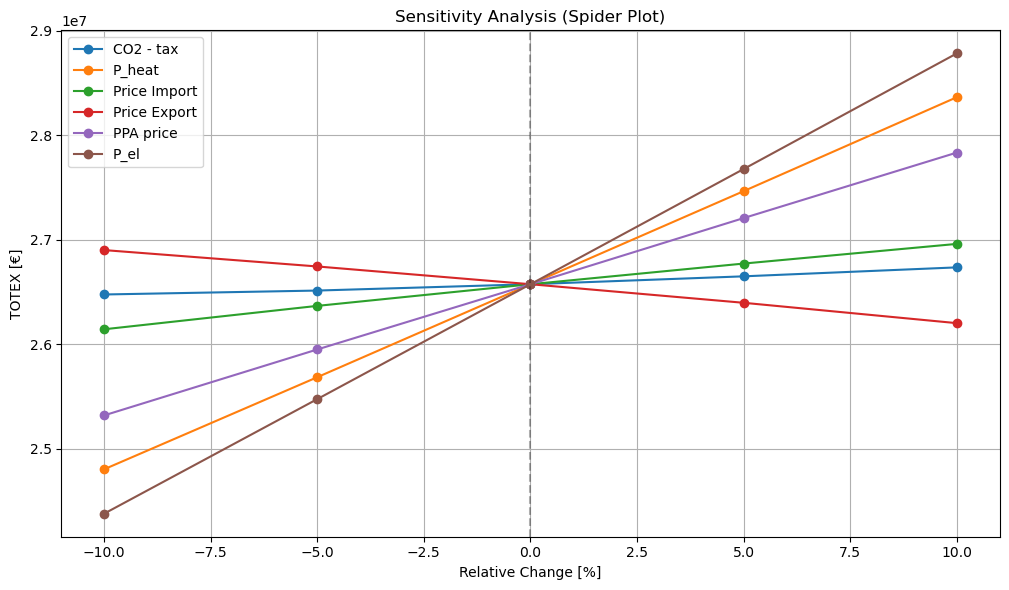

In [141]:
# --- 5. PLOT ---
spider_data.plot(marker='o', figsize=(10, 6))
plt.axvline(0, color='black', linestyle='--', alpha=0.3) # Reference line at baseline
plt.title("Sensitivity Analysis (Spider Plot)")
plt.xlabel("Relative Change [%]")
plt.tight_layout()
plt.ylabel("TOTEX [€]")
plt.grid(True)
plt.legend()
plt.show()

<Axes: xlabel='snapshot'>

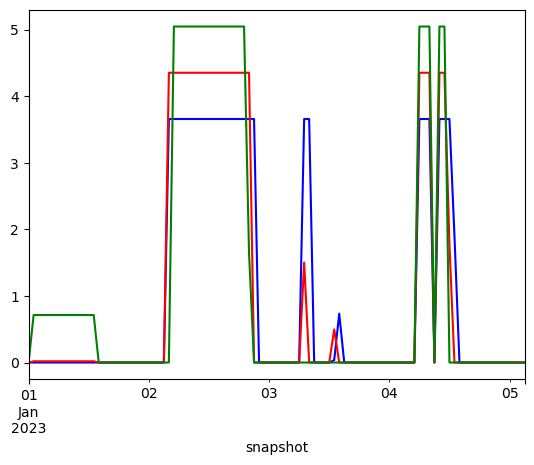

In [176]:
n_sens_heat[1].links_t.p0["TES_Rondo_to_Heat_Bus_Skive"][:100].plot(color = "blue")
n_sens_heat[2].links_t.p0["TES_Rondo_to_Heat_Bus_Skive"][:100].plot(color = "red")
n_sens_heat[3].links_t.p0["TES_Rondo_to_Heat_Bus_Skive"][:100].plot(color = "green")

<Axes: xlabel='snapshot'>

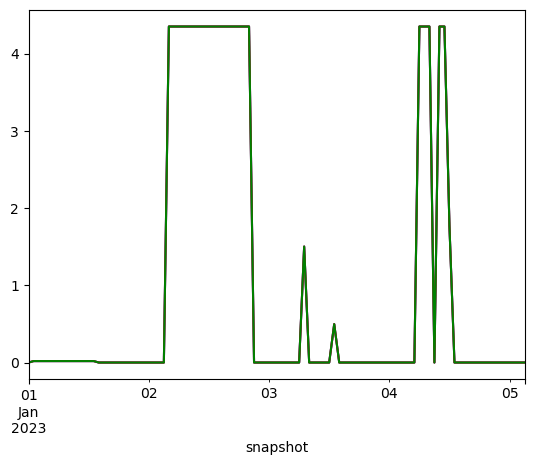

In [181]:
n_sens_CO2[1].links_t.p0["TES_Rondo_to_Heat_Bus_Skive"][0:100].plot(color = "blue")
n_sens_CO2[2].links_t.p0["TES_Rondo_to_Heat_Bus_Skive"][0:100].plot(color = "red")
n_sens_CO2[3].links_t.p0["TES_Rondo_to_Heat_Bus_Skive"][0:100].plot(color = "green")

<Axes: xlabel='snapshot'>

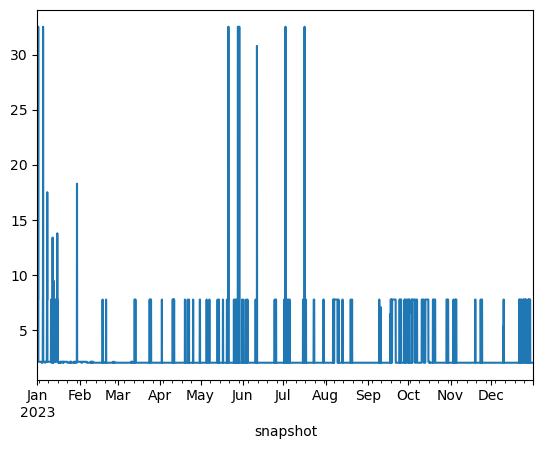

In [842]:
n.links_t.p0["PPA"].plot()

In [844]:
n.storage_units_t.state_of_charge["Skive_Battery"].sum() # MWh

161528.5690980416

In [845]:
"Annualised CAPEX of Battery X BAttery Capacity";

(costs.at["battery inverter", "capital_cost"] + 4 * costs.at["battery storage", "capital_cost"])*22/n.storage_units_t.p_dispatch["Skive_Battery"].sum()
# Dividing by the Total Power Dispatched by the Battery

# EUR/MWh

76.55286062216989

In [846]:
#(-n.links_t.p0["El_to_TES_Rondo"]).plot()
n.links_t.p0["TES_Rondo_to_Heat_Bus_Skive"].sum()

489.63406171399436

In [847]:

(costs.at["Concrete-discharger", "capital_cost"]*7)/(n.links_t.p0["TES_Rondo_to_Heat_Bus_Skive"]).sum()

659.0137968019361

In [848]:
n.buses_t.marginal_price

Bus,Greenlab,EuroWind,Grid_Import,Grid_Export,Heat_Exchanger_Bus,TES_Rondo,Heat_MT,Heat_Sink,NG,pellets,biochar,biochar sequestration
snapshot,,,,,,,,,,,,
2023-01-01 00:00:00,94.256289,1.428600,0.000005,0.0,83.783368,95.025728,104.729210,104.729210,143.215220,62.0,13.12,0.0
2023-01-01 01:00:00,94.256289,1.428600,0.000005,0.0,83.783368,96.179886,104.729210,104.729210,143.215220,62.0,13.12,0.0
2023-01-01 02:00:00,94.256289,1.428600,0.000005,0.0,83.783368,95.025728,104.729210,104.729210,143.215220,62.0,13.12,0.0
2023-01-01 03:00:00,94.256289,1.428600,0.000005,0.0,83.783368,96.179886,104.729210,104.729210,143.215220,62.0,13.12,0.0
2023-01-01 04:00:00,94.256289,1.428600,0.000005,0.0,83.783368,95.025728,104.729210,104.729210,143.215220,62.0,13.12,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-31 19:00:00,127.330702,33.510781,0.000005,0.0,89.556373,89.459389,111.945467,111.945467,109.706557,62.0,13.12,0.0
2023-12-31 20:00:00,121.877095,28.220782,0.000005,0.0,89.556373,90.545940,111.945467,111.945467,109.706557,62.0,13.12,0.0
2023-12-31 21:00:00,120.918332,27.290782,0.000005,0.0,89.556373,91.645688,111.945467,111.945467,109.706557,62.0,13.12,0.0


In [849]:
"Checking if Heat Load Matched the Heat Supply";
(-n.links_t.p1["pyrolysis"][0:24*7]) + (-n.links_t.p1["Heat_Exchanger_Rondo"][0:24*7]) + (-n.links_t.p1["Boiler_Skive"][0:24*7])+ (-n.links_t.p1["NG boiler"][0:24*7])

snapshot
2023-01-01 00:00:00    5.0
2023-01-01 01:00:00    5.0
2023-01-01 02:00:00    5.0
2023-01-01 03:00:00    5.0
2023-01-01 04:00:00    5.0
                      ... 
2023-01-07 19:00:00    5.0
2023-01-07 20:00:00    5.0
2023-01-07 21:00:00    5.0
2023-01-07 22:00:00    5.0
2023-01-07 23:00:00    5.0
Length: 168, dtype: float64

In [850]:
-n.links_t.p1["Heat_Exchanger_Rondo"]

snapshot
2023-01-01 00:00:00    0.0
2023-01-01 01:00:00    0.0
2023-01-01 02:00:00    0.0
2023-01-01 03:00:00    0.0
2023-01-01 04:00:00    0.0
                      ... 
2023-12-31 19:00:00    0.0
2023-12-31 20:00:00    0.0
2023-12-31 21:00:00    0.0
2023-12-31 22:00:00    0.0
2023-12-31 23:00:00    0.0
Name: Heat_Exchanger_Rondo, Length: 8760, dtype: float64

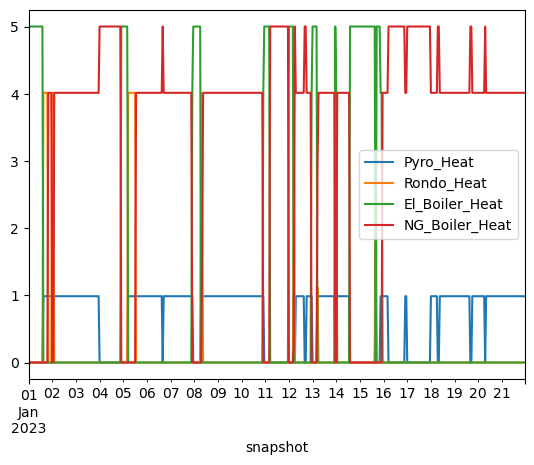

In [851]:
(-n.links_t.p1["pyrolysis"][0:24*7*3]).plot(label="Pyro_Heat")
(-n.links_t.p1["Heat_Exchanger_Rondo"][0:24*7*3]).plot(label="Rondo_Heat")
(-n.links_t.p1["Boiler_Skive"][0:24*7*3]).plot(label="El_Boiler_Heat")
(-n.links_t.p1["NG boiler"][0:24*7*3]).plot(label="NG_Boiler_Heat")
plt.legend()


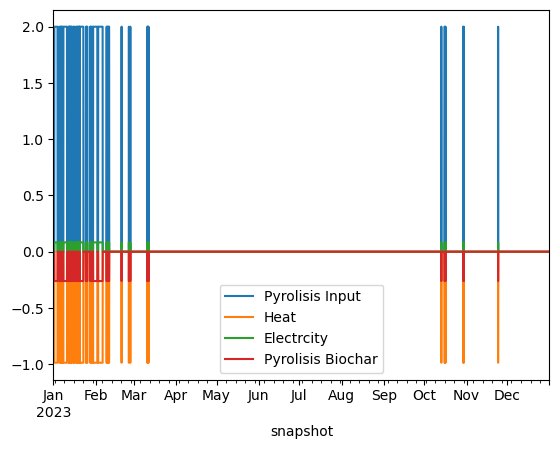

In [ ]:
# Pyrolisis Input;
n.links_t.p0["pyrolysis"].plot(label="Pyrolisis Input")
# Pyrolisis Output:
n.links_t.p1["pyrolysis"].plot(label="Heat")
n.links_t.p2["pyrolysis"].plot(label="Electrcity")
n.links_t.p3["pyrolysis"].plot(label="Pyrolisis Biochar")

plt.legend()

<Axes: xlabel='snapshot'>

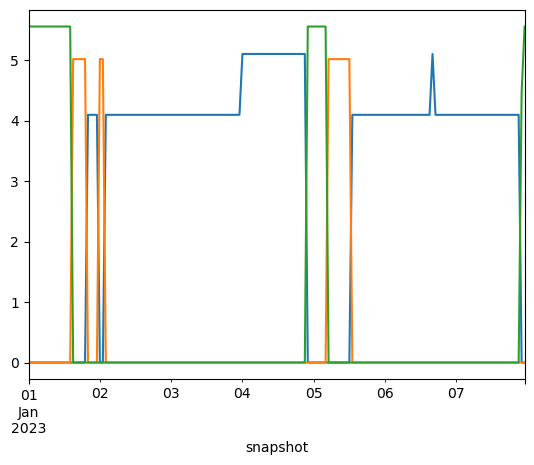

In [852]:
n.links_t.p0["NG boiler"][0:24*7].plot()
n.links_t.p0["Heat_Exchanger_Rondo"][0:24*7].plot()
n.links_t.p0["Boiler_Skive"][0:24*7].plot()

<Axes: xlabel='snapshot'>

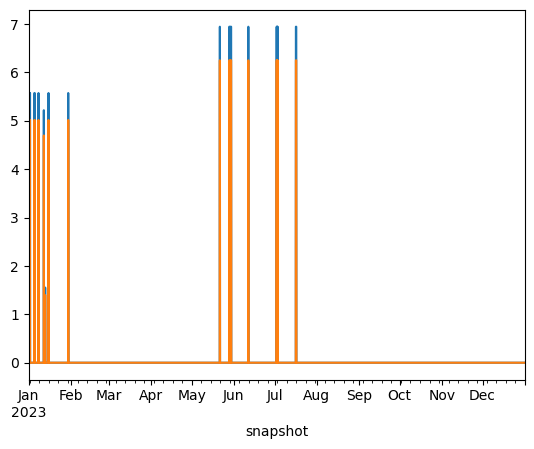

In [855]:
(n.links_t.p0["TES_Rondo_to_Heat_Bus_Skive"]).plot()
n.links_t.p0["Heat_Exchanger_Rondo"].plot()

In [856]:
n.links.p_nom_opt

Link
PPA                            32.531501
Imports                        84.000000
Exports                        84.000000
MT_Heat_Supply                  5.000000
El_to_TES_Rondo                24.000000
TES_Rondo_to_Heat_Bus_Skive     7.000000
Heat_Exchanger_Rondo            6.250000
Boiler_Skive                   10.000000
NG boiler                       6.000000
pyrolysis                       2.000000
biochar sequestration           0.260593
Name: p_nom_opt, dtype: float64

In [857]:
n.stores.e_nom_opt

Store
Grid_Store                     122164.450646
Rondo_Concrete_Heat_Storage       100.000000
biochar sequestred                167.821963
Name: e_nom_opt, dtype: float64

In [858]:
n.generators

,bus,control,type,p_nom,p_nom_mod,p_nom_extendable,p_nom_min,p_nom_max,p_min_pu,p_max_pu,...,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down,weight,p_nom_opt
Generator,,,,,,,,,,,,,,,,,,,,,
Skive_Solar,EuroWind,PQ,,36.0,0.0,False,0.0,inf,0.0,1.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,36.000000
Skive_Onshore_Wind,EuroWind,PQ,,54.0,0.0,False,0.0,inf,0.0,1.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,54.000000
Grid_Generator,Grid_Import,PQ,,0.0,0.0,True,0.0,inf,0.0,1.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,56.218042
NG grid,NG,PQ,,6.0,0.0,False,0.0,inf,0.0,1.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,6.000000
pellets input,pellets,PQ,,0.0,0.0,True,0.0,inf,0.0,1.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,2.000000


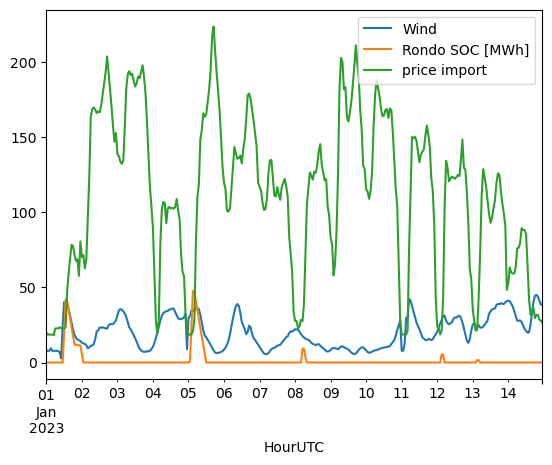

In [861]:
#(n.generators_t.p["Skive_Solar"])[0:24*7*2].plot(label ="Solar")
(n.generators_t.p["Skive_Onshore_Wind"])[0:24*7*2].plot(label ="Wind")
n.stores_t.e['Rondo_Concrete_Heat_Storage'][0:24*7*2].plot(label = "Rondo SOC [MWh]")
price_import23[0:24*7*2].plot(label = "price import")
plt.legend()

In [1]:
n.stores_t.e['Rondo_Concrete_Heat_Storage'][0:24*7*6].plot(label = "Rondo SOC [MWh]")
n.links_t.p0["PPA"][0:24*7*6].plot(label = "PPA [MW]")
plt.legend()

NameError: name 'n' is not defined